<a href="https://colab.research.google.com/github/Icarusleo/Stock-Price-Direction-Prediction/blob/main/Stock_Price_Direction_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Pre-processing**

In [ ]:
!pip install yfinance pandas numpy torch torchvision transformers  pywavelets ta newsapi-python pandas_ta


  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 4.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 240.3/240.3 kB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.9/3.9 MB 67.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 138.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.5/16.5 MB 116.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.4/42.4 MB 58.3 MB/s eta 0:00:00
  Created wheel for ta: filename=ta-0.11.0-py3-none-any.whl size=29412 sha256=199f3a859190a0211a3d5c2ec0d50d837fe8809cc50529c2a33501e81b6a15b3
  Stored in directory: /root/.cache/pip/wheels/5c/a1/5f/c6b85a7d9452057be4ce68a8e45d77ba34234a6d46581777c6
Successfully built ta
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninst

In [ ]:
!pip install arch


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 14.9 MB/s eta 0:00:00


In [ ]:

import yfinance as yf
import pandas as pd
import pandas_ta as ta

TICKER = 'MRK'
START_DATE = '2010-01-01'
END_DATE = '2020-06-11'

data = yf.download(TICKER, start=START_DATE, end=END_DATE)

if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.get_level_values(0)

if data.empty:
    print(f"Veri çekilemedi. Ticker: {TICKER}")
else:
    print(f"'{TICKER}' için {len(data)} satır ham OHLCV verisi çekildi.")
    print("--- Ham Veri (Düzeltilmiş Sütunlar) ---")
    print(data.tail())

    # fiyat değişimlerinin hızı ve büyüklüğü
    data.ta.rsi(length=14, append=True)

    #trendin yönü
    data.ta.macd(fast=12, slow=26, signal=9, append=True)

    # oynaklık
    data.ta.bbands(length=20, std=2, append=True)

    #Volatilite ölçer
    data.ta.atr(length=14, append=True)

    data.dropna(inplace=True)

    print(data.tail())


/tmp/ipython-input-2118246379.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(TICKER, start=START_DATE, end=END_DATE)
[*********************100%***********************]  1 of 1 completed


'MRK' için 2627 satır ham OHLCV verisi çekildi.
--- Ham Veri (Düzeltilmiş Sütunlar) ---
Price           Close       High        Low       Open    Volume
Date                                                            
2020-06-04  64.881454  65.366773  64.316575  64.658681   9292930
2020-06-05  65.446342  66.138519  64.833733  65.327004  10413347
2020-06-08  65.955544  66.194227  64.563239  64.563239   9956838
2020-06-09  65.446342  66.440848  65.334962  66.186254   8846168
2020-06-10  65.056496  65.860053  64.435922  65.589550   9080920
Price           Close       High        Low       Open    Volume     RSI_14  \
Date                                                                          
2020-06-04  64.881454  65.366773  64.316575  64.658681   9292930  58.358359   
2020-06-05  65.446342  66.138519  64.833733  65.327004  10413347  60.275042   
2020-06-08  65.955544  66.194227  64.563239  64.563239   9956838  61.974120   
2020-06-09  65.446342  66.440848  65.334962  66.186254   88461

In [ ]:
import numpy as np


data['Target'] = (data['Close'].shift(-1) > data['Close']).astype(int)
data = data.iloc[:-1]

print("--- Hedef Değişkeni 'Target' Eklendi (Son satır atıldı) ---")
print(data[['Close', 'Target']].tail())

print("\n--- Mevcut Sütun İsimleri ---")
print(data.columns.tolist())

stationary_cols = ['Target', 'RSI_14', 'MACD_12_26_9', 'MACDh_12_26_9', 'MACDs_12_26_9']

non_stationary_cols = [col for col in data.columns if col not in stationary_cols]

print(f"\nİşlem yapılacak (durağan olmayan) {len(non_stationary_cols)} sütun bulundu:")
print(non_stationary_cols)

epsilon = 1e-9

# Log-returns hesaplaması (SADECE dinamik olarak seçilen sütunlara)
for col in non_stationary_cols:
    # Hem paya hem paydaya epsilon ekleyerek (0/0) veya (x/0) hatalarını önle
    data[col] = np.log((data[col] + epsilon) / (data[col].shift(1) + epsilon))


# Log-returns aldığımızda, veri setindeki *ilk* satır 'NaN' olacaktır
# (çünkü t-1 yoktur). Bu satırı da atmalıyız.
data.dropna(inplace=True)

print("\n--- Veri Durağanlaştırıldı (Log-Returns Uygulandı) ---")
print(data.head())
print("\n--- Veri Setinin Son Hali ---")
print(data.tail())

--- Hedef Değişkeni 'Target' Eklendi (Son satır atıldı) ---
Price           Close  Target
Date                         
2020-06-03  65.287224       0
2020-06-04  64.881454       1
2020-06-05  65.446342       1
2020-06-08  65.955544       0
2020-06-09  65.446342       0

--- Mevcut Sütun İsimleri ---
['Close', 'High', 'Low', 'Open', 'Volume', 'RSI_14', 'MACD_12_26_9', 'MACDh_12_26_9', 'MACDs_12_26_9', 'BBL_20_2.0_2.0', 'BBM_20_2.0_2.0', 'BBU_20_2.0_2.0', 'BBB_20_2.0_2.0', 'BBP_20_2.0_2.0', 'ATRr_14', 'Target']

İşlem yapılacak (durağan olmayan) 11 sütun bulundu:
['Close', 'High', 'Low', 'Open', 'Volume', 'BBL_20_2.0_2.0', 'BBM_20_2.0_2.0', 'BBU_20_2.0_2.0', 'BBB_20_2.0_2.0', 'BBP_20_2.0_2.0', 'ATRr_14']

--- Veri Durağanlaştırıldı (Log-Returns Uygulandı) ---
Price          Close      High       Low      Open    Volume     RSI_14  \
Date                                                                      
2010-02-23 -0.016569 -0.019200 -0.005479 -0.025683 -0.098109  42.187630   
2010-02

/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [ ]:
import pandas as pd

NEWS_CSV_PATH = '/content/drive/MyDrive/Stock Price Direction Prediction/Dataset/analyst_ratings_processed.csv'

print(f"'{NEWS_CSV_PATH}' dosyası yükleniyor...")
try:
    news_df = pd.read_csv(NEWS_CSV_PATH)
except FileNotFoundError:
    print(f"HATA: '{NEWS_CSV_PATH}' dosyası bulunamadı.")
    raise

print("Dosya yüklendi. 'stock' sütunu analiz ediliyor...")

clean_tickers = news_df['stock'].dropna().astype(str).str.upper()

unique_tickers = clean_tickers.unique()

print("\n--- Analiz Sonucu ---")
print(f"Dosyada toplam {len(unique_tickers)} adet benzersiz hisse senedi (ticker) bulundu.")

if len(unique_tickers) > 0:
    print("\nİlk 100 Ticker (alfabetik sıralı):")
    print(sorted(unique_tickers)[:100])
else:
    print("HATA: 'stock' sütunu tamamen boş veya okunamadı.")

if TICKER in unique_tickers:
    print("\nSONUÇ: ",TICKER, "listede VAR.")
elif TICKER in unique_tickers:
    print("\nSONUÇ: ",TICKER," yok, ancak 'APPLE' var.")
else:
    print("\nSONUÇ: ",TICKER," listede bulunamadı.")

'/content/drive/MyDrive/Stock Price Direction Prediction/Dataset/analyst_ratings_processed.csv' dosyası yükleniyor...
Dosya yüklendi. 'stock' sütunu analiz ediliyor...

--- Analiz Sonucu ---
Dosyada toplam 6192 adet benzersiz hisse senedi (ticker) bulundu.

İlk 100 Ticker (alfabetik sıralı):
['A', 'AAMC', 'AAME', 'AAN', 'AAOI', 'AAON', 'AAP', 'AAPL', 'AAU', 'AAV', 'AAVL', 'AAWW', 'AAXJ', 'AB', 'ABAC', 'ABAX', 'ABB', 'ABBV', 'ABC', 'ABCB', 'ABCD', 'ABCO', 'ABCW', 'ABDC', 'ABEV', 'ABG', 'ABGB', 'ABIO', 'ABM', 'ABMD', 'ABR', 'ABTL', 'ABX', 'ABY', 'ACAD', 'ACAS', 'ACAT', 'ACC', 'ACCO', 'ACCU', 'ACE', 'ACET', 'ACFC', 'ACFN', 'ACG', 'ACGL', 'ACH', 'ACHC', 'ACHN', 'ACIW', 'ACLS', 'ACM', 'ACMP', 'ACN', 'ACNB', 'ACOR', 'ACP', 'ACPW', 'ACRE', 'ACRX', 'ACSF', 'ACST', 'ACT', 'ACTA', 'ACTG', 'ACTS', 'ACU', 'ACUR', 'ACWI', 'ACWV', 'ACWX', 'ACXM', 'ACY', 'ADAT', 'ADBE', 'ADC', 'ADEP', 'ADES', 'ADGE', 'ADHD', 'ADI', 'ADK', 'ADM', 'ADMA', 'ADMP', 'ADMS', 'ADNC', 'ADP', 'ADPT', 'ADRA', 'ADRD', 'ADRE', '

In [ ]:
import pandas as pd

TICKER = 'MRK'

print(f"--- {TICKER} için Sayısal Veri (Adım 2'den) ---")
print(data.tail(3))

NEWS_CSV_PATH = '/content/drive/MyDrive/Stock Price Direction Prediction/Dataset/analyst_ratings_processed.csv'

try:
    news_df = pd.read_csv(NEWS_CSV_PATH)
except FileNotFoundError:
    print(f"HATA: '{NEWS_CSV_PATH}' dosyası bulunamadı.")
    raise

print("\n--- Yüklenen Ham Haber Verisi (CSV) ---")
print(news_df.head())

import pandas as pd

TICKER = 'MRK'

print(f"--- {TICKER} için Sayısal Veri (Adım 2'den) ---")
print(data.tail(3))

NEWS_CSV_PATH = '/content/drive/MyDrive/Stock Price Direction Prediction/Dataset/analyst_ratings_processed.csv'

try:
    news_df = pd.read_csv(NEWS_CSV_PATH)
except FileNotFoundError:
    print(f"HATA: '{NEWS_CSV_PATH}' dosyası bulunamadı.")
    raise

print("\n--- Yüklenen Ham Haber Verisi (CSV) ---")
print(news_df.head())

import pandas as pd

TICKER = 'MRK'

if 'daily_news' in data.columns:
    data = data.drop(columns=['daily_news'])


news_df['date'] = pd.to_datetime(news_df['date'], utc=True, errors='coerce')

news_df = news_df.dropna(subset=['date'])

news_df['date'] = news_df['date'].dt.tz_localize(None)

news_df_filtered = news_df[news_df['stock'] == TICKER].copy()

news_df_filtered['date_only'] = news_df_filtered['date'].dt.date
daily_news = news_df_filtered.groupby('date_only')['title'].apply(lambda x: ' . '.join(x)).reset_index()

daily_news.columns = ['Date', 'daily_news']
daily_news['Date'] = pd.to_datetime(daily_news['Date'])

if not isinstance(data.index, pd.DatetimeIndex):
    data.index = pd.to_datetime(data.index)

merged_data = data.merge(daily_news, left_index=True, right_on='Date', how='left')

merged_data['daily_news'] = merged_data['daily_news'].fillna("")
merged_data.set_index('Date', inplace=True)

data = merged_data

print(f"\n--- HATA GİDERİLDİ VE BİRLEŞTİRME TAMAMLANDI: {TICKER} ---")
print(f"Toplam Satır: {len(data)}")
print(data[['Close', 'daily_news']].tail(5))

--- MRK için Sayısal Veri (Adım 2'den) ---
Price          Close      High       Low      Open    Volume     RSI_14  \
Date                                                                      
2020-06-05  0.008669  0.011737  0.008009  0.010283  0.113834  60.275042   
2020-06-08  0.007750  0.000842 -0.004181 -0.011760 -0.044829  61.974120   
2020-06-09 -0.007750  0.003719  0.011882  0.024828 -0.118275  59.245219   

Price       MACD_12_26_9  MACDh_12_26_9  MACDs_12_26_9  BBL_20_2.0_2.0  \
Date                                                                     
2020-06-05      0.597476       0.413986       0.183490        0.003284   
2020-06-08      0.731471       0.438385       0.293086        0.001458   
2020-06-09      0.787497       0.395529       0.391968        0.000588   

Price       BBM_20_2.0_2.0  BBU_20_2.0_2.0  BBB_20_2.0_2.0  BBP_20_2.0_2.0  \
Date                                                                         
2020-06-05        0.004232        0.005091        0.01

In [ ]:
news_df['date'] = pd.to_datetime(news_df['date'], errors='coerce')

news_df_filtered = news_df[news_df['stock'] == TICKER].copy()
toplam_mrk = len(news_df_filtered)

bozuk_mrk = news_df_filtered['date'].isna().sum()

print(f"--- MRK Veri Analizi ---")
print(f"Toplam MRK haberi: {toplam_mrk}")
print(f"Bozuk tarihli MRK haberi: {bozuk_mrk}")
print(f"Kalan sağlam haber: {toplam_mrk - bozuk_mrk}")

news_df_filtered.dropna(subset=['date'], inplace=True)

--- MRK Veri Analizi ---
Toplam MRK haberi: 3334
Bozuk tarihli MRK haberi: 0
Kalan sağlam haber: 3334


In [ ]:
print("\n--- Haberin Olduğu Bölüm (Haziran 2020) ---")
data.info()


--- Haberin Olduğu Bölüm (Haziran 2020) ---
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2446 entries, 2010-02-23 to 2020-06-09
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Close           2446 non-null   float64
 1   High            2446 non-null   float64
 2   Low             2446 non-null   float64
 3   Open            2446 non-null   float64
 4   Volume          2446 non-null   float64
 5   RSI_14          2446 non-null   float64
 6   MACD_12_26_9    2446 non-null   float64
 7   MACDh_12_26_9   2446 non-null   float64
 8   MACDs_12_26_9   2446 non-null   float64
 9   BBL_20_2.0_2.0  2446 non-null   float64
 10  BBM_20_2.0_2.0  2446 non-null   float64
 11  BBU_20_2.0_2.0  2446 non-null   float64
 12  BBB_20_2.0_2.0  2446 non-null   float64
 13  BBP_20_2.0_2.0  2446 non-null   float64
 14  ATRr_14         2446 non-null   float64
 15  Target          2446 non-null   int64  
 16  daily_news     

In [ ]:

# Mantık: Yarınki kapanış fiyatı bugünkünden yüksekse 1 (Yükseliş), değilse 0 (Düşüş)
data['Target'] = (data['Close'].shift(-1) > data['Close']).astype(int)

# shift(-1) işlemi nedeniyle en son satırın "yarınki fiyatı" bilinmediği için NaN olacaktır.
# Bu satırı eğitimde kullanamayacağımız için siliyoruz.
data = data.dropna(subset=['Target'])

print("--- 'Target' Sütunu Eklendi ---")
print(data[['Close', 'Target']].tail())
print(f"\nYeni Veri Seti Boyutu: {data.shape}")

--- 'Target' Sütunu Eklendi ---
               Close  Target
Date                        
2020-06-03  0.014979       0
2020-06-04 -0.006235       1
2020-06-05  0.008668       0
2020-06-08  0.007750       0
2020-06-09 -0.007750       0

Yeni Veri Seti Boyutu: (2446, 17)


In [ ]:
data.head()

,Close,High,Low,Open,Volume,RSI_14,MACD_12_26_9,MACDh_12_26_9,MACDs_12_26_9,BBL_20_2.0_2.0,BBM_20_2.0_2.0,BBU_20_2.0_2.0,BBB_20_2.0_2.0,BBP_20_2.0_2.0,ATRr_14,Target,daily_news
Date,,,,,,,,,,,,,,,,,
2010-02-23,-0.016570,-0.019201,-0.005480,-0.025684,-0.098109,42.187397,-0.279555,0.047185,-0.326740,-0.002660,-0.002995,-0.003298,-0.006546,-0.479170,-0.018358,1,
2010-02-24,0.011438,-0.002696,-0.003578,-0.005435,0.070193,46.235303,-0.271138,0.044482,-0.315620,-0.000764,-0.002202,-0.003508,-0.028639,0.467423,-0.015120,0,
2010-02-25,-0.009796,-0.010313,-0.006085,-0.007110,-0.003340,43.428397,-0.277448,0.030537,-0.307986,-0.001299,-0.002769,-0.004109,-0.030215,-0.252209,-0.005980,1,Eli Lilly Banks On Its Restructured Developmen...
2010-02-26,0.008441,0.010852,0.010760,0.007110,-0.257538,46.443530,-0.265457,0.034022,-0.299480,-0.001050,-0.001461,-0.001837,-0.008632,0.321552,-0.025347,1,
2010-03-01,0.010519,0.009935,0.016062,0.008952,-0.109178,50.050341,-0.235710,0.051016,-0.286726,0.000266,-0.001222,-0.002582,-0.031866,0.290184,-0.029646,0,Karen Finerman Thinks There Might Be Other Bid...


In [ ]:
train_split = 0.7
val_split = 0.15
n_rows = len(data)

train_idx = int(n_rows * train_split)
val_idx = int(n_rows * (train_split + val_split))

train_df = data.iloc[:train_idx]
val_df = data.iloc[train_idx:val_idx]
test_df = data.iloc[val_idx:]

print("\n--- Veri Bölümlemesi Tamamlandı ---")
print(f"Toplam Veri: {n_rows} satır")
print(f"Eğitim Seti (Train): {len(train_df)} satır ({train_df.index.min().date()} - {train_df.index.max().date()})")
print(f"Doğrulama Seti (Val): {len(val_df)} satır ({val_df.index.min().date()} - {val_df.index.max().date()})")
print(f"Test Seti (Test): {len(test_df)} satır ({test_df.index.min().date()} - {test_df.index.max().date()})")


train_df.to_pickle("/content/drive/MyDrive/Stock Price Direction Prediction/Dataset/train_data.pkl")
val_df.to_pickle("/content/drive/MyDrive/Stock Price Direction Prediction/Dataset/val_data.pkl")
test_df.to_pickle("/content/drive/MyDrive/Stock Price Direction Prediction/Dataset/test_data.pkl")


--- Veri Bölümlemesi Tamamlandı ---
Toplam Veri: 2594 satır
Eğitim Seti (Train): 1815 satır (2010-02-22 - 2017-05-05)
Doğrulama Seti (Val): 389 satır (2017-05-08 - 2018-11-19)
Test Seti (Test): 390 satır (2018-11-20 - 2020-06-10)


In [ ]:
import numpy as np
import pandas as pd
from tensorflow.keras.utils import to_categorical

train_df = pd.read_pickle("/content/drive/MyDrive/Stock Price Direction Prediction/Dataset/train_data.pkl")
val_df = pd.read_pickle("/content/drive/MyDrive/Stock Price Direction Prediction/Dataset/val_data.pkl")
test_df = pd.read_pickle("/content/drive/MyDrive/Stock Price Direction Prediction/Dataset/test_data.pkl")

SEQUENCE_LENGTH = 10
MAX_LEN = 128

exclude_cols = ['Target', 'daily_news', 'input_ids', 'attention_mask']
numerical_cols = [col for col in train_df.columns if col not in exclude_cols]
NUM_FEATURES = len(numerical_cols)

print(f"Sayısal özellik (feature) sayısı: {NUM_FEATURES}")
print(f"Sayısal özellikler: {numerical_cols}")

def create_sequences(df, seq_length):
    X_numerical_list = []
    X_ids_list = []
    X_mask_list = []
    y_list = []

    numerical_data = df[numerical_cols].values
    ids_data = np.array(df['input_ids'].tolist())
    mask_data = np.array(df['attention_mask'].tolist())
    target_data = df['Target'].values

    for i in range(len(df) - seq_length):
        X_numerical_list.append(numerical_data[i : (i + seq_length)])
        X_ids_list.append(ids_data[i : (i + seq_length)])
        X_mask_list.append(mask_data[i : (i + seq_length)])
        y_list.append(target_data[i + seq_length])

    return (
        (np.array(X_numerical_list), np.array(X_ids_list), np.array(X_mask_list)),
        np.array(y_list)
    )
print("\nEğitim (Train) seti dizilere dönüştürülüyor...")

(X_train_num, X_train_ids, X_train_mask), y_train = create_sequences(train_df, SEQUENCE_LENGTH)

print("Doğrulama (Validation) seti dizilere dönüştürülüyor...")
(X_val_num, X_val_ids, X_val_mask), y_val = create_sequences(val_df, SEQUENCE_LENGTH)

print("Test seti dizilere dönüştürülüyor...")
(X_test_num, X_test_ids, X_test_mask), y_test = create_sequences(test_df, SEQUENCE_LENGTH)


print("\n--- Diziye Dönüştürme Tamamlandı ---")
print(f"X_train (Sayısal) şekli: {X_train_num.shape}")
print(f"X_train (Token IDs) şekli: {X_train_ids.shape}")
print(f"y_train (Hedef) şekli: {y_train.shape}")
print("\nÖrnek:")
print(f"Sayısal Veri: (Örnek Sayısı, Dizi Uzunluğu, Özellik Sayısı) -> {X_train_num.shape}")
print(f"Metin Verisi: (Örnek Sayısı, Dizi Uzunluğu, Token Uzunluğu) -> {X_train_ids.shape}")

Sayısal özellik (feature) sayısı: 15
Sayısal özellikler: ['Close', 'High', 'Low', 'Open', 'Volume', 'RSI_14', 'MACD_12_26_9', 'MACDh_12_26_9', 'MACDs_12_26_9', 'BBL_20_2.0_2.0', 'BBM_20_2.0_2.0', 'BBU_20_2.0_2.0', 'BBB_20_2.0_2.0', 'BBP_20_2.0_2.0', 'ATRr_14']

Eğitim (Train) seti dizilere dönüştürülüyor...
Doğrulama (Validation) seti dizilere dönüştürülüyor...
Test seti dizilere dönüştürülüyor...

--- Diziye Dönüştürme Tamamlandı ---
X_train (Sayısal) şekli: (1805, 10, 15)
X_train (Token IDs) şekli: (1805, 10, 128)
y_train (Hedef) şekli: (1805,)

Örnek:
Sayısal Veri: (Örnek Sayısı, Dizi Uzunluğu, Özellik Sayısı) -> (1805, 10, 15)
Metin Verisi: (Örnek Sayısı, Dizi Uzunluğu, Token Uzunluğu) -> (1805, 10, 128)


#**FİNBERT + CNN + LSTM**

In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import (
    Layer, Input, Conv1D, LSTM, Dense, Dropout,
    Concatenate, Lambda
)
from tensorflow.keras.models import Model
from transformers import TFBertModel



class BertLayer(Layer):
    def __init__(self, bert_model, **kwargs):
        super(BertLayer, self).__init__(**kwargs)
        self.bert = bert_model
        self.output_dim = self.bert.config.hidden_size

    def call(self, inputs):
        input_ids, attention_mask = inputs
        outputs = self.bert(
            {'input_ids': input_ids, 'attention_mask': attention_mask}
        )
        return outputs.pooler_output



def build_finbert_cnn_lstm(seq_len, num_features, max_len):

    print("FinBERT (TFBertModel) yükleniyor...")
    bert_model = TFBertModel.from_pretrained("ProsusAI/finbert", from_pt=True)
    bert_model.trainable = False
    print("FinBERT yüklendi ve donduruldu.")

    custom_bert_layer = BertLayer(bert_model, name="custom_bert_layer")

    bert_input_ids = Input(shape=(max_len,), dtype="int32")
    bert_input_mask = Input(shape=(max_len,), dtype="int32")
    bert_output = custom_bert_layer([bert_input_ids, bert_input_mask])

    finbert_sub_model = Model(
        inputs=[bert_input_ids, bert_input_mask],
        outputs=bert_output,
        name="finbert_feature_extractor"
    )

    input_numerical = Input(shape=(seq_len, num_features), name="numerical_input")
    input_ids = Input(shape=(seq_len, max_len), dtype="int32", name="input_ids")
    input_mask = Input(shape=(seq_len, max_len), dtype="int32", name="input_mask")

    flat_ids = Lambda(lambda x: tf.reshape(x, (-1, max_len)),
                      name="flat_ids")(input_ids)

    flat_mask = Lambda(lambda x: tf.reshape(x, (-1, max_len)),
                       name="flat_mask")(input_mask)

    bert_features_2d = finbert_sub_model([flat_ids, flat_mask])

    text_features = Lambda(
        lambda x: tf.reshape(x, (-1, seq_len, bert_features_2d.shape[-1])),
        name="restore_seq"
    )(bert_features_2d)

    # --- CNN ---
    cnn_out = Conv1D(
        filters=64,
        kernel_size=3,
        padding="same",
        activation="relu"
    )(input_numerical)

    # --- MERGE ---
    combined = Concatenate(axis=-1)([cnn_out, text_features])

    # --- LSTM ---
    lstm_out = LSTM(100)(combined)

    # --- OUTPUT ---
    x = Dense(64, activation="relu")(lstm_out)
    x = Dropout(0.5)(x)
    output = Dense(1, activation="sigmoid")(x)

    model = Model(
        inputs=[input_numerical, input_ids, input_mask],
        outputs=output
    )

    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model

print("Model fonksiyonu 'build_finbert_cnn_lstm' tanımlandı.")
print("Test amacıyla model mimarisi oluşturuluyor...")

SEQUENCE_LENGTH = X_train_num.shape[1]
NUM_FEATURES = X_train_num.shape[2]
MAX_LEN = X_train_ids.shape[2]

model_deneme = build_finbert_cnn_lstm(SEQUENCE_LENGTH, NUM_FEATURES, MAX_LEN)
model_deneme.summary()

print("\nModel özeti başarıyla oluşturuldu.")
print("Artık Adım 6 (Walk-Forward Eğitim Döngüsü) için hazırız.")

Model fonksiyonu 'build_finbert_cnn_lstm' tanımlandı.
Test amacıyla model mimarisi oluşturuluyor...
FinBERT (TFBertModel) yükleniyor...


Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFBertModel: ['bert.embeddings.position_ids', 'classifier.bias', 'classifier.weight']
- This IS expected if you are initializing TFBertModel from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFBertModel from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
All the weights of TFBertModel were initialized from the PyTorch model.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFBertModel for predictions without further training.


FinBERT yüklendi ve donduruldu.


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_ids           │ (None, 10, 128)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_mask          │ (None, 10, 128)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flat_ids (Lambda)   │ (None, 128)       │          0 │ input_ids[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flat_mask (Lambda)  │ (None, 128)       │          0 │ input_mask[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ numerical_input     │ (None, 10, 15)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ finbert_feature_ex… │ (None, 768)       │          0 │ flat_ids[0][0],   │
│ (Functional)        │                   │            │ flat_mask[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 10, 64)    │      2,944 │ numerical_input[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ restore_seq         │ (None, 10, 768)   │          0 │ finbert_feature_… │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 10, 832)   │          0 │ conv1d_1[0][0],   │
│ (Concatenate)       │                   │            │ restore_seq[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 100)       │    373,200 │ concatenate_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 64)        │      6,464 │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64)        │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 1)         │         65 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 382,673 (1.46 MB)

 Trainable params: 382,673 (1.46 MB)

 Non-trainable params: 0 (0.00 B)


Model özeti başarıyla oluşturuldu.
Artık Adım 6 (Walk-Forward Eğitim Döngüsü) için hazırız.


In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Lambda, Layer
from tensorflow.keras.models import Model
from transformers import TFBertModel

# 1. BertLayer Sınıfını Tanımlama
class BertLayer(Layer):
    def __init__(self, bert_model, **kwargs):
        super(BertLayer, self).__init__(**kwargs)
        self.bert = bert_model

    def call(self, inputs):
        input_ids, attention_mask = inputs
        outputs = self.bert({'input_ids': input_ids, 'attention_mask': attention_mask})
        return outputs.pooler_output

# 2. FinBERT Modelini Yükleme ve Dondurma
print("FinBERT yükleniyor...")
bert_base = TFBertModel.from_pretrained("ProsusAI/finbert", from_pt=True)
bert_base.trainable = False # Ağırlıkları donduruyoruz (Dürüstlük ilkesi)

# 3. FinBERT Alt Modelini (Feature Extractor) Oluşturma
MAX_LEN = 128
bert_in_ids = Input(shape=(MAX_LEN,), dtype="int32", name="bert_input_ids")
bert_in_mask = Input(shape=(MAX_LEN,), dtype="int32", name="bert_input_mask")
bert_out = BertLayer(bert_base)([bert_in_ids, bert_in_mask])

finbert_sub_model = Model(inputs=[bert_in_ids, bert_in_mask], outputs=bert_out, name="finbert_sub_model")
print("finbert_sub_model başarıyla tanımlandı.")

FinBERT yükleniyor...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/758 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

TensorFlow and JAX classes are deprecated and will be removed in Transformers v5. We recommend migrating to PyTorch classes or pinning your version of Transformers.
Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFBertModel: ['bert.embeddings.position_ids', 'classifier.bias', 'classifier.weight']
- This IS expected if you are initializing TFBertModel from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFBertModel from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
All the weights of TFBertModel were initialized from the PyTorch model.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFBertModel for predictions without further trai

finbert_sub_model başarıyla tanımlandı.


In [ ]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import matthews_corrcoef, classification_report
from tensorflow.keras.callbacks import EarlyStopping
import numpy as np
import pandas as pd

try:
    X_all_num = np.concatenate([X_train_num, X_val_num, X_test_num])
    X_all_ids = np.concatenate([X_train_ids, X_val_ids, X_test_ids])
    X_all_mask = np.concatenate([X_train_mask, X_val_mask, X_test_mask])
    y_all = np.concatenate([y_train, y_val, y_test])
except NameError:
    print("HATA: X_train_num, y_train vb. değişkenler hafızada bulunamadı.")
    print("Lütfen Adım 5.A'yı (Dizi Oluşturma) tekrar çalıştırdığınızdan emin olun.")
    raise

print(f"Walk-Forward için tam veri seti birleştirildi: {len(y_all)} adet dizi (sequence).")

N_SPLITS = 5
tscv = TimeSeriesSplit(n_splits=N_SPLITS)

SEQUENCE_LENGTH = X_all_num.shape[1]
NUM_FEATURES = X_all_num.shape[2]
MAX_LEN = X_all_ids.shape[2]

fold_mcc_scores = []
fold = 1

print(f"\n--- 🚀 {N_SPLITS} Parçalı Walk-Forward Eğitim Döngüsü Başlıyor ---")

for train_index, test_index in tscv.split(X_all_num):
    print(f"\n--- FOLD {fold}/{N_SPLITS} ---")

    X_train_fold = [X_all_num[train_index], X_all_ids[train_index], X_all_mask[train_index]]
    X_test_fold = [X_all_num[test_index], X_all_ids[test_index], X_all_mask[test_index]]

    y_train_fold = y_all[train_index]
    y_test_fold = y_all[test_index]


    val_split_size = int(len(y_train_fold) * 0.15)

    X_val_fold = [arr[-val_split_size:] for arr in X_train_fold]
    y_val_fold = y_train_fold[-val_split_size:]

    X_train_fold = [arr[:-val_split_size] for arr in X_train_fold]
    y_train_fold = y_train_fold[:-val_split_size]

    print(f"Eğitim: {len(y_train_fold)} dizi | Doğrulama: {len(y_val_fold)} dizi | Test: {len(y_test_fold)} dizi")

    print("Model sıfırdan oluşturuluyor...")
    model = build_finbert_cnn_lstm(SEQUENCE_LENGTH, NUM_FEATURES, MAX_LEN)

    print(f"Fold {fold} eğitiliyor...")
    model.fit(
        X_train_fold,
        y_train_fold,
        validation_data=(X_val_fold, y_val_fold),
        epochs=15,
        batch_size=32,
        callbacks=[EarlyStopping(monitor='val_loss', patience=3, verbose=1, restore_best_weights=True)],
        verbose=1
    )

    print(f"Fold {fold} test ediliyor...")
    y_pred_proba = model.predict(X_test_fold)
    y_pred_binary = (y_pred_proba > 0.5).astype(int)

    mcc = matthews_corrcoef(y_test_fold, y_pred_binary)
    fold_mcc_scores.append(mcc)

    print("\n--- FOLD {fold} PERFORMANSI ---")
    print(f"🎯 Matthews Korelasyon Katsayısı (MCC): {mcc:.4f}")
    print("\nDetaylı Sınıflandırma Raporu:")
    print(classification_report(y_test_fold, y_pred_binary, target_names=['Düşüş (0)', 'Yükseliş (1)']))

    fold += 1

print("\n--- 🏁 Walk-Forward Eğitim Döngüsü Tamamlandı ---")
print(f"Tüm {N_SPLITS} döngü için MCC skorları: {fold_mcc_scores}")
print(f"\nModelin Ortalama (Mean) MCC Skoru: {np.mean(fold_mcc_scores):.4f}")
print(f"MCC Skorlarının Standart Sapması: {np.std(fold_mcc_scores):.4f}")

Walk-Forward için tam veri seti birleştirildi: 2564 adet dizi (sequence).

--- 🚀 5 Parçalı Walk-Forward Eğitim Döngüsü Başlıyor ---

--- FOLD 1/5 ---
Eğitim: 365 dizi | Doğrulama: 64 dizi | Test: 427 dizi
Model sıfırdan oluşturuluyor...
FinBERT (TFBertModel) yükleniyor...


Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFBertModel: ['bert.embeddings.position_ids', 'classifier.bias', 'classifier.weight']
- This IS expected if you are initializing TFBertModel from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFBertModel from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
All the weights of TFBertModel were initialized from the PyTorch model.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFBertModel for predictions without further training.


FinBERT yüklendi ve donduruldu.
Fold 1 eğitiliyor...
Epoch 1/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 47s 3s/step - accuracy: 0.4935 - loss: 0.7220 - val_accuracy: 0.4688 - val_loss: 0.6970
Epoch 2/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 34s 3s/step - accuracy: 0.5304 - loss: 0.7088 - val_accuracy: 0.3750 - val_loss: 0.7055
Epoch 3/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 35s 3s/step - accuracy: 0.4612 - loss: 0.7250 - val_accuracy: 0.4375 - val_loss: 0.6951
Epoch 4/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 35s 3s/step - accuracy: 0.5418 - loss: 0.6947 - val_accuracy: 0.3125 - val_loss: 0.7100
Epoch 5/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 35s 3s/step - accuracy: 0.5671 - loss: 0.6902 - val_accuracy: 0.4219 - val_loss: 0.7097
Epoch 6/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 35s 3s/step - accuracy: 0.4795 - loss: 0.7003 - val_accuracy: 0.4062 - val_loss: 0.7078
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 3.
Fold 1 test ediliyor...
14/14 ━━━━━━━━━━━━━━━━━━━━ 39s 3s/step

--- FOLD {fold} PERFORMANSI ---
🎯 Matthews K

Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFBertModel: ['bert.embeddings.position_ids', 'classifier.bias', 'classifier.weight']
- This IS expected if you are initializing TFBertModel from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFBertModel from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
All the weights of TFBertModel were initialized from the PyTorch model.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFBertModel for predictions without further training.


FinBERT yüklendi ve donduruldu.
Fold 2 eğitiliyor...
Epoch 1/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 83s 3s/step - accuracy: 0.4739 - loss: 0.7363 - val_accuracy: 0.4844 - val_loss: 0.6986
Epoch 2/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 70s 3s/step - accuracy: 0.4886 - loss: 0.7197 - val_accuracy: 0.4453 - val_loss: 0.7081
Epoch 3/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 70s 3s/step - accuracy: 0.4935 - loss: 0.7101 - val_accuracy: 0.4922 - val_loss: 0.7018
Epoch 4/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 70s 3s/step - accuracy: 0.4540 - loss: 0.7168 - val_accuracy: 0.4609 - val_loss: 0.7002
Epoch 4: early stopping
Restoring model weights from the end of the best epoch: 1.
Fold 2 test ediliyor...
14/14 ━━━━━━━━━━━━━━━━━━━━ 39s 3s/step

--- FOLD {fold} PERFORMANSI ---
🎯 Matthews Korelasyon Katsayısı (MCC): -0.0062

Detaylı Sınıflandırma Raporu:
              precision    recall  f1-score   support

   Düşüş (0)       0.48      0.42      0.45       208
Yükseliş (1)       0.51      0.57      0.54       219

    accuracy          

...

FinBERT yüklendi ve donduruldu.
Fold 3 eğitiliyor...
Epoch 1/15
35/35 ━━━━━━━━━━━━━━━━━━━━ 120s 3s/step - accuracy: 0.4912 - loss: 0.7282 - val_accuracy: 0.4844 - val_loss: 0.6966
Epoch 2/15
35/35 ━━━━━━━━━━━━━━━━━━━━ 105s 3s/step - accuracy: 0.4893 - loss: 0.7186 - val_accuracy: 0.4740 - val_loss: 0.6956
Epoch 3/15
35/35 ━━━━━━━━━━━━━━━━━━━━ 105s 3s/step - accuracy: 0.4799 - loss: 0.7124 - val_accuracy: 0.5312 - val_loss: 0.6901
Epoch 4/15
35/35 ━━━━━━━━━━━━━━━━━━━━ 105s 3s/step - accuracy: 0.4980 - loss: 0.7011 - val_accuracy: 0.5104 - val_loss: 0.6921
Epoch 5/15
35/35 ━━━━━━━━━━━━━━━━━━━━ 105s 3s/step - accuracy: 0.5307 - loss: 0.6958 - val_accuracy: 0.5208 - val_loss: 0.6927
Epoch 6/15
35/35 ━━━━━━━━━━━━━━━━━━━━ 105s 3s/step - accuracy: 0.5137 - loss: 0.6944 - val_accuracy: 0.5104 - val_loss: 0.6924
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 3.
Fold 3 test ediliyor...
14/14 ━━━━━━━━━━━━━━━━━━━━ 39s 3s/step

--- FOLD {fold} PERFORMANSI ---
🎯 Matt

Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFBertModel: ['bert.embeddings.position_ids', 'classifier.bias', 'classifier.weight']
- This IS expected if you are initializing TFBertModel from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFBertModel from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
All the weights of TFBertModel were initialized from the PyTorch model.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFBertModel for predictions without further training.


FinBERT yüklendi ve donduruldu.
Fold 4 eğitiliyor...
Epoch 1/15
46/46 ━━━━━━━━━━━━━━━━━━━━ 153s 3s/step - accuracy: 0.5226 - loss: 0.7198 - val_accuracy: 0.5352 - val_loss: 0.6931
Epoch 2/15
46/46 ━━━━━━━━━━━━━━━━━━━━ 140s 3s/step - accuracy: 0.5052 - loss: 0.7136 - val_accuracy: 0.4883 - val_loss: 0.6977
Epoch 3/15
46/46 ━━━━━━━━━━━━━━━━━━━━ 140s 3s/step - accuracy: 0.5003 - loss: 0.7095 - val_accuracy: 0.4922 - val_loss: 0.6972
Epoch 4/15
46/46 ━━━━━━━━━━━━━━━━━━━━ 140s 3s/step - accuracy: 0.5088 - loss: 0.7039 - val_accuracy: 0.4844 - val_loss: 0.6977
Epoch 4: early stopping
Restoring model weights from the end of the best epoch: 1.
Fold 4 test ediliyor...
14/14 ━━━━━━━━━━━━━━━━━━━━ 39s 3s/step

--- FOLD {fold} PERFORMANSI ---
🎯 Matthews Korelasyon Katsayısı (MCC): -0.0127

Detaylı Sınıflandırma Raporu:
              precision    recall  f1-score   support

   Düşüş (0)       0.49      0.43      0.46       212
Yükseliş (1)       0.50      0.56      0.53       215

    accuracy      

Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFBertModel: ['bert.embeddings.position_ids', 'classifier.bias', 'classifier.weight']
- This IS expected if you are initializing TFBertModel from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFBertModel from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
All the weights of TFBertModel were initialized from the PyTorch model.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFBertModel for predictions without further training.


FinBERT yüklendi ve donduruldu.
Fold 5 eğitiliyor...
Epoch 1/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 188s 3s/step - accuracy: 0.5043 - loss: 0.7220 - val_accuracy: 0.4812 - val_loss: 0.7027
Epoch 2/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 174s 3s/step - accuracy: 0.5296 - loss: 0.7069 - val_accuracy: 0.5125 - val_loss: 0.6919
Epoch 3/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 174s 3s/step - accuracy: 0.5134 - loss: 0.7004 - val_accuracy: 0.5031 - val_loss: 0.6923
Epoch 4/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 174s 3s/step - accuracy: 0.5073 - loss: 0.6978 - val_accuracy: 0.5156 - val_loss: 0.6913
Epoch 5/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 174s 3s/step - accuracy: 0.4954 - loss: 0.7009 - val_accuracy: 0.5094 - val_loss: 0.6915
Epoch 6/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 174s 3s/step - accuracy: 0.5092 - loss: 0.6966 - val_accuracy: 0.5063 - val_loss: 0.6921
Epoch 7/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 175s 3s/step - accuracy: 0.5018 - loss: 0.6965 - val_accuracy: 0.5406 - val_loss: 0.6899
Epoch 8/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 174s 3s/step - accur

12/12 ━━━━━━━━━━━━━━━━━━━━ 31s 3s/step


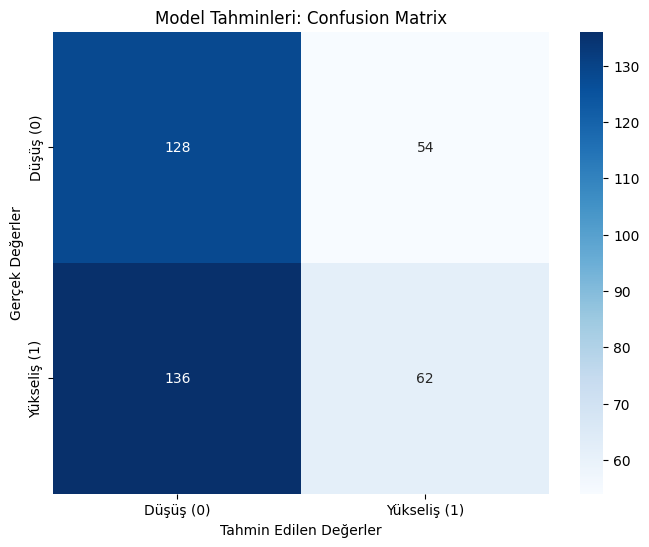


DETAYLI SINIFLANDIRMA RAPORU
              precision    recall  f1-score   support

   Düşüş (0)       0.48      0.70      0.57       182
Yükseliş (1)       0.53      0.31      0.39       198

    accuracy                           0.50       380
   macro avg       0.51      0.51      0.48       380
weighted avg       0.51      0.50      0.48       380

Genel Doğruluk (Accuracy): %50.00


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

def evaluate_model_performance(y_true, y_pred_probs, threshold=0.5):
    """
    Model performansını Confusion Matrix ve Classification Report ile analiz eder.
    """
    y_pred_classes = (y_pred_probs > threshold).astype("int32")

    cm = confusion_matrix(y_true, y_pred_classes)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Düşüş (0)', 'Yükseliş (1)'],
                yticklabels=['Düşüş (0)', 'Yükseliş (1)'])
    plt.title('Model Tahminleri: Confusion Matrix')
    plt.ylabel('Gerçek Değerler')
    plt.xlabel('Tahmin Edilen Değerler')
    plt.show()

    print("\n" + "="*30)
    print("DETAYLI SINIFLANDIRMA RAPORU")
    print("="*30)
    print(classification_report(y_true, y_pred_classes, target_names=['Düşüş (0)', 'Yükseliş (1)']))

    acc = accuracy_score(y_true, y_pred_classes)
    print(f"Genel Doğruluk (Accuracy): %{acc*100:.2f}")


y_pred_probs = model.predict([X_test_num, X_test_ids, X_test_mask])
evaluate_model_performance(y_test, y_pred_probs)

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# **FINBERT + CNN + BILSTM**

In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import (
    Layer, Input, Conv1D, LSTM, Dense, Dropout,
    Concatenate, Lambda, Bidirectional, BatchNormalization
)
from tensorflow.keras.models import Model
from transformers import TFBertModel

class BertLayer(Layer):
    def __init__(self, bert_model, **kwargs):
        super(BertLayer, self).__init__(**kwargs)
        self.bert = bert_model

    def call(self, inputs):
        input_ids, attention_mask = inputs

        input_ids = tf.cast(input_ids, tf.int32)
        attention_mask = tf.cast(attention_mask, tf.int32)

        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        return outputs.pooler_output

def build_final_multimodal_bi_lstm(seq_len, num_features, max_len):
    bert_model = TFBertModel.from_pretrained("ProsusAI/finbert", from_pt=True)
    bert_model.trainable = False  # BERT ağırlıklarını donduruyoruz
    custom_bert_layer = BertLayer(bert_model, name="finbert_layer")

    # --- INPUTLAR ---
    input_numerical = Input(shape=(seq_len, num_features), name="numerical_input")
    input_ids = Input(shape=(seq_len, max_len), dtype="int32", name="input_ids")
    input_mask = Input(shape=(seq_len, max_len), dtype="int32", name="input_mask")

    # --- METİN İŞLEME ---
    flat_ids = Lambda(lambda x: tf.cast(tf.reshape(x, (-1, max_len)), tf.int32), name="flat_ids")(input_ids)
    flat_mask = Lambda(lambda x: tf.cast(tf.reshape(x, (-1, max_len)), tf.int32), name="flat_mask")(input_mask)

    bert_output = custom_bert_layer([flat_ids, flat_mask])

    # Tekrar zaman serisi formatına geri döndürüyoruz (Batch, Seq_Len, BERT_Dim)
    text_features = Lambda(
        lambda x: tf.reshape(x, (-1, seq_len, bert_output.shape[-1])),
        name="text_feature_reshape"
    )(bert_output)

    # --- SAYISAL İŞLEME (Technical Stream) ---
    # Yerel trendleri yakalamak için CNN katmanı
    cnn_out = Conv1D(filters=64, kernel_size=3, padding="same", activation="relu")(input_numerical)
    cnn_out = BatchNormalization()(cnn_out)

    # --- MULTIMODAL FUSION (Birleştirme) ---
    combined = Concatenate(axis=-1, name="fusion_layer")([cnn_out, text_features])

    # --- BIDIRECTIONAL LSTM BLOĞU ---
    # Birinci katman: Çift yönlü, tüm zaman adımlarını döner
    bi_lstm_1 = Bidirectional(LSTM(128, return_sequences=True, dropout=0.2))(combined)

    # İkinci katman: Çift yönlü, son vektörü döner
    bi_lstm_2 = Bidirectional(LSTM(64, return_sequences=False, dropout=0.2))(bi_lstm_1)

    # --- ÇIKIŞ KATMANLARI ---
    x = Dense(64, activation="relu")(bi_lstm_2)
    x = Dropout(0.5)(x)
    x = Dense(32, activation="relu")(x)
    output = Dense(1, activation="sigmoid", name="prediction")(x)

    # Modeli derleme
    model = Model(inputs=[input_numerical, input_ids, input_mask], outputs=output)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
        loss="binary_crossentropy",
        metrics=["accuracy", tf.keras.metrics.AUC(name='auc')]
    )

    return model

SEQUENCE_LENGTH = X_train_num.shape[1]
NUM_FEATURES = X_train_num.shape[2]
MAX_LEN = X_train_ids.shape[2]

model = build_final_multimodal_bi_lstm(SEQUENCE_LENGTH, NUM_FEATURES, MAX_LEN)
model.summary()

Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFBertModel: ['classifier.weight', 'classifier.bias', 'bert.embeddings.position_ids']
- This IS expected if you are initializing TFBertModel from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFBertModel from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
All the weights of TFBertModel were initialized from the PyTorch model.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFBertModel for predictions without further training.


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_ids           │ (None, 10, 128)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_mask          │ (None, 10, 128)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ numerical_input     │ (None, 10, 15)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flat_ids (Lambda)   │ (None, 128)       │          0 │ input_ids[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flat_mask (Lambda)  │ (None, 128)       │          0 │ input_mask[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 10, 64)    │      2,944 │ numerical_input[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ finbert_layer       │ (None, 768)       │          0 │ flat_ids[0][0],   │
│ (BertLayer)         │                   │            │ flat_mask[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 10, 64)    │        256 │ conv1d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ text_feature_resha… │ (None, 10, 768)   │          0 │ finbert_layer[0]… │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fusion_layer        │ (None, 10, 832)   │          0 │ batch_normalizat… │
│ (Concatenate)       │                   │            │ text_feature_res… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 10, 256)   │    984,064 │ fusion_layer[0][… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_1     │ (None, 128)       │    164,352 │ bidirectional[0]… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │      8,256 │ bidirectional_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 64)        │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 32)        │      2,080 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ prediction (Dense)  │ (None, 1)         │         33 │ dense_1[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,161,985 (4.43 MB)

 Trainable params: 1,161,857 (4.43 MB)

 Non-trainable params: 128 (512.00 B)

In [ ]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import matthews_corrcoef, classification_report
from tensorflow.keras.callbacks import EarlyStopping
import numpy as np
import pandas as pd

try:
    X_all_num = np.concatenate([X_train_num, X_val_num, X_test_num])
    X_all_ids = np.concatenate([X_train_ids, X_val_ids, X_test_ids])
    X_all_mask = np.concatenate([X_train_mask, X_val_mask, X_test_mask])
    y_all = np.concatenate([y_train, y_val, y_test])
except NameError:
    print("HATA: X_train_num, y_train vb. değişkenler hafızada bulunamadı.")
    print("Lütfen Adım 5.A'yı (Dizi Oluşturma) tekrar çalıştırdığınızdan emin olun.")
    raise

print(f"Walk-Forward için tam veri seti birleştirildi: {len(y_all)} adet dizi (sequence).")

N_SPLITS = 5
tscv = TimeSeriesSplit(n_splits=N_SPLITS)

SEQUENCE_LENGTH = X_all_num.shape[1]
NUM_FEATURES = X_all_num.shape[2]
MAX_LEN = X_all_ids.shape[2]

fold_mcc_scores = []
fold = 1

print(f"\n--- 🚀 {N_SPLITS} Parçalı Walk-Forward Eğitim Döngüsü Başlıyor ---")

for train_index, test_index in tscv.split(X_all_num):
    print(f"\n--- FOLD {fold}/{N_SPLITS} ---")

    X_train_fold = [X_all_num[train_index], X_all_ids[train_index], X_all_mask[train_index]]
    X_test_fold = [X_all_num[test_index], X_all_ids[test_index], X_all_mask[test_index]]

    y_train_fold = y_all[train_index]
    y_test_fold = y_all[test_index]


    val_split_size = int(len(y_train_fold) * 0.15)

    X_val_fold = [arr[-val_split_size:] for arr in X_train_fold]
    y_val_fold = y_train_fold[-val_split_size:]

    X_train_fold = [arr[:-val_split_size] for arr in X_train_fold]
    y_train_fold = y_train_fold[:-val_split_size]

    print(f"Eğitim: {len(y_train_fold)} dizi | Doğrulama: {len(y_val_fold)} dizi | Test: {len(y_test_fold)} dizi")

    print("Model sıfırdan oluşturuluyor...")
    model = build_finbert_cnn_lstm(SEQUENCE_LENGTH, NUM_FEATURES, MAX_LEN)

    print(f"Fold {fold} eğitiliyor...")
    model.fit(
        X_train_fold,
        y_train_fold,
        validation_data=(X_val_fold, y_val_fold),
        epochs=15,
        batch_size=32,
        callbacks=[EarlyStopping(monitor='val_loss', patience=3, verbose=1, restore_best_weights=True)],
        verbose=1
    )

    print(f"Fold {fold} test ediliyor...")
    y_pred_proba = model.predict(X_test_fold)
    y_pred_binary = (y_pred_proba > 0.5).astype(int)

    mcc = matthews_corrcoef(y_test_fold, y_pred_binary)
    fold_mcc_scores.append(mcc)

    print("\n--- FOLD {fold} PERFORMANSI ---")
    print(f"🎯 Matthews Korelasyon Katsayısı (MCC): {mcc:.4f}")
    print("\nDetaylı Sınıflandırma Raporu:")
    print(classification_report(y_test_fold, y_pred_binary, target_names=['Düşüş (0)', 'Yükseliş (1)']))

    fold += 1

print("\n--- 🏁 Walk-Forward Eğitim Döngüsü Tamamlandı ---")
print(f"Tüm {N_SPLITS} döngü için MCC skorları: {fold_mcc_scores}")
print(f"\nModelin Ortalama (Mean) MCC Skoru: {np.mean(fold_mcc_scores):.4f}")
print(f"MCC Skorlarının Standart Sapması: {np.std(fold_mcc_scores):.4f}")

Walk-Forward için tam veri seti birleştirildi: 2564 adet dizi (sequence).

--- 🚀 5 Parçalı Walk-Forward Eğitim Döngüsü Başlıyor ---

--- FOLD 1/5 ---
Eğitim: 365 dizi | Doğrulama: 64 dizi | Test: 427 dizi
Model sıfırdan oluşturuluyor...
Fold 1 eğitiliyor...
Epoch 1/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 35s 2s/step - accuracy: 0.5360 - auc: 0.5444 - loss: 0.6901 - val_accuracy: 0.6562 - val_auc: 0.4833 - val_loss: 0.6859
Epoch 2/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step - accuracy: 0.5398 - auc: 0.5365 - loss: 0.6923 - val_accuracy: 0.6250 - val_auc: 0.4792 - val_loss: 0.6831
Epoch 3/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step - accuracy: 0.5235 - auc: 0.5490 - loss: 0.6891 - val_accuracy: 0.6250 - val_auc: 0.5365 - val_loss: 0.6852
Epoch 4/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step - accuracy: 0.5319 - auc: 0.5445 - loss: 0.6881 - val_accuracy: 0.6250 - val_auc: 0.4740 - val_loss: 0.6859
Epoch 5/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step - accuracy: 0.5486 - auc: 0.5558 - loss: 0.6871 - val_accura

12/12 ━━━━━━━━━━━━━━━━━━━━ 13s 1s/step


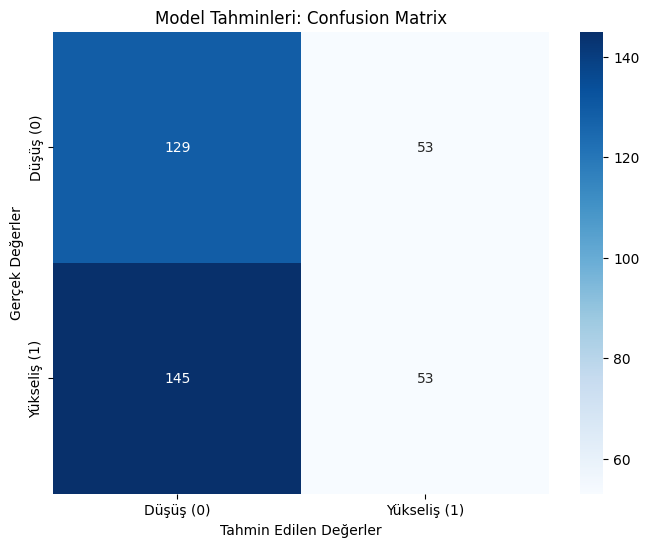


DETAYLI SINIFLANDIRMA RAPORU
              precision    recall  f1-score   support

   Düşüş (0)       0.47      0.71      0.57       182
Yükseliş (1)       0.50      0.27      0.35       198

    accuracy                           0.48       380
   macro avg       0.49      0.49      0.46       380
weighted avg       0.49      0.48      0.45       380

Genel Doğruluk (Accuracy): %47.89


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

def evaluate_model_performance(y_true, y_pred_probs, threshold=0.5):
    """
    Model performansını Confusion Matrix ve Classification Report ile analiz eder.
    """
    y_pred_classes = (y_pred_probs > threshold).astype("int32")

    cm = confusion_matrix(y_true, y_pred_classes)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Düşüş (0)', 'Yükseliş (1)'],
                yticklabels=['Düşüş (0)', 'Yükseliş (1)'])
    plt.title('Model Tahminleri: Confusion Matrix')
    plt.ylabel('Gerçek Değerler')
    plt.xlabel('Tahmin Edilen Değerler')
    plt.show()

    print("\n" + "="*30)
    print("DETAYLI SINIFLANDIRMA RAPORU")
    print("="*30)
    print(classification_report(y_true, y_pred_classes, target_names=['Düşüş (0)', 'Yükseliş (1)']))

    acc = accuracy_score(y_true, y_pred_classes)
    print(f"Genel Doğruluk (Accuracy): %{acc*100:.2f}")


y_pred_probs = model.predict([X_test_num, X_test_ids, X_test_mask])
evaluate_model_performance(y_test, y_pred_probs)

# **LSTM İLE GOOGLE 1 YILLIK**

In [ ]:
import pandas as pd
google_data = pd.read_pickle('/content/drive/MyDrive/Stock Price Direction Prediction/Dataset/GOOG.pkl')

In [ ]:
test_size = 30
simulation_size = 10

df_train = google_data.iloc[:-test_size]
df_test = google_data.iloc[-test_size:]

val_size = int(len(df_train) * 0.2)
df_train = df_train.iloc[:-val_size]
df_val = df_train.iloc[-val_size:]
google_data.shape, google_data.shape, df_test.shape

((209, 16), (209, 16), (30, 16))

In [ ]:
import numpy as np
from sklearn.preprocessing import StandardScaler

NUM_FEATURES = ['Close', 'High', 'Low', 'Open', 'Volume', ]

def prepare_numerical_only(df, window_size=5, scaler=None, fit_scaler=False):
    if fit_scaler:
        scaler = StandardScaler()
        scaled_data = scaler.fit_transform(df[NUM_FEATURES])
    else:
        scaled_data = scaler.transform(df[NUM_FEATURES])

    X, y = [], []
    for i in range(window_size, len(df)):
        X.append(scaled_data[i-window_size:i])
        y.append(df.iloc[i]['Target'])

    return np.array(X, dtype='float32'), np.array(y, dtype='float32'), scaler

X_train_num, y_train, scaler = prepare_numerical_only(df_train, fit_scaler=True)
X_val_num, y_val, _ = prepare_numerical_only(df_val, scaler=scaler)
X_test_num, y_test, _ = prepare_numerical_only(df_test, scaler=scaler)

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization

def build_numeric_model(window_size, feature_count):
    model = Sequential([
        LSTM(128, return_sequences=True, input_shape=(window_size, feature_count)),
        BatchNormalization(),
        Dropout(0.3),

        LSTM(64, return_sequences=False),
        BatchNormalization(),
        Dropout(0.3),

        Dense(32, activation='relu'),
        Dense(1, activation='sigmoid')
    ])

    optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4)
    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])

    return model

model_num = build_numeric_model(window_size=5, feature_count=len(NUM_FEATURES))

In [ ]:
import os
import tensorflow as tf

class SaveEveryNEpochs(tf.keras.callbacks.Callback):
    def __init__(self, save_freq=10, save_dir="/content/drive/MyDrive/Stock Price Direction Prediction/only_LSTM"):
        super().__init__()
        self.save_freq = save_freq
        self.save_dir = save_dir
        os.makedirs(save_dir, exist_ok=True)

    def on_epoch_end(self, epoch, logs=None):
        # epoch 0'dan başlar → +1 gerçek epoch
        if (epoch + 1) % self.save_freq == 0:
            path = os.path.join(
                self.save_dir,
                f"model_epoch_{epoch+1}.keras"
            )
            self.model.save(path)
            print(f"\n✅ Model kaydedildi: {path}")


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau


checkpoint_path = "/content/drive/MyDrive/Stock Price Direction Prediction/best_model_LSTM.keras"
callbacks = [

    ModelCheckpoint(checkpoint_path, monitor='val_loss', save_best_only=True, verbose=1),

    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-7, verbose=1),
    SaveEveryNEpochs(save_freq=10)

]

history_num = model_num.fit(
    X_train_num, y_train,
    validation_data=(X_val_num, y_val),
    epochs=200,
    batch_size=16,
    callbacks=callbacks,
    shuffle=False
)

Epoch 1/200
8/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6086 - loss: 0.7025
Epoch 1: val_loss improved from inf to 0.69504, saving model to /content/drive/MyDrive/Stock Price Direction Prediction/best_model_LSTM.keras
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 71ms/step - accuracy: 0.6078 - loss: 0.7083 - val_accuracy: 0.3667 - val_loss: 0.6950 - learning_rate: 1.0000e-04
Epoch 2/200
8/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6011 - loss: 0.7382 
Epoch 2: val_loss improved from 0.69504 to 0.69432, saving model to /content/drive/MyDrive/Stock Price Direction Prediction/best_model_LSTM.keras
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.6017 - loss: 0.7356 - val_accuracy: 0.4667 - val_loss: 0.6943 - learning_rate: 1.0000e-04
Epoch 3/200
8/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5555 - loss: 0.8006 
Epoch 3: val_loss improved from 0.69432 to 0.69383, saving model to /content/drive/MyDrive/Stock Price Direction Prediction/best_model_LSTM.keras
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 25m

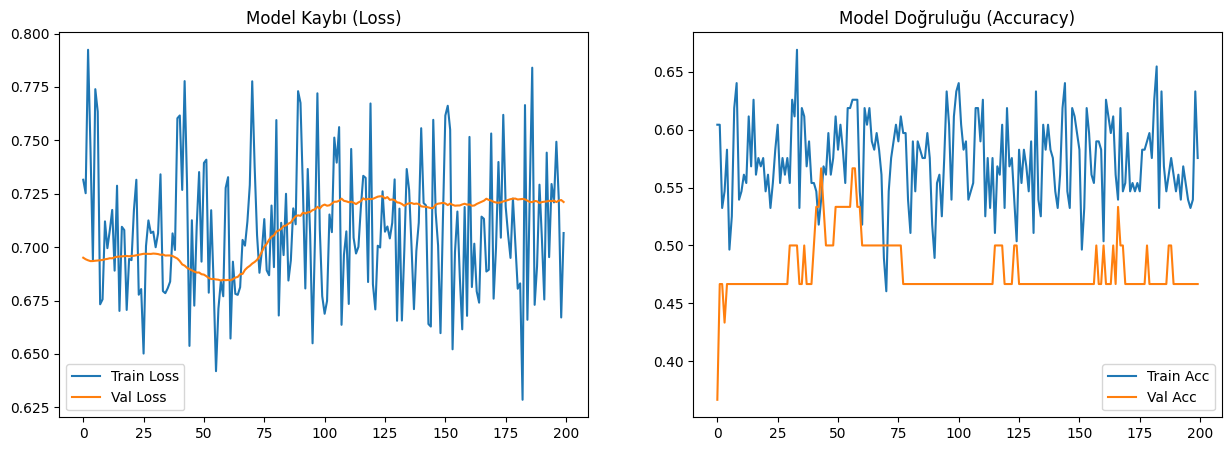

In [ ]:
import matplotlib.pyplot as plt

def plot_history(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    # Loss grafiği
    ax1.plot(history.history['loss'], label='Train Loss')
    ax1.plot(history.history['val_loss'], label='Val Loss')
    ax1.set_title('Model Kaybı (Loss)')
    ax1.legend()

    # Accuracy grafiği
    ax2.plot(history.history['accuracy'], label='Train Acc')
    ax2.plot(history.history['val_accuracy'], label='Val Acc')
    ax2.set_title('Model Doğruluğu (Accuracy)')
    ax2.legend()

    plt.show()

plot_history(history_num)

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Test seti üzerinden tahminleri al (olasılık olarak)
y_pred_probs = model_num.predict(X_test_num)

# Olasılıkları sınıflara dönüştür (Threshold = 0.5)
y_pred = (y_pred_probs > 0.5).astype(int)

# Karmaşıklık Matrisini Hesapla
cm = confusion_matrix(y_test, y_pred)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 230ms/step


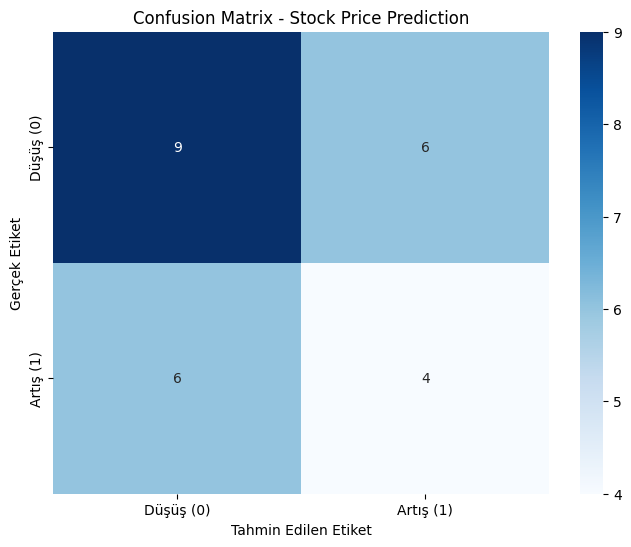

              precision    recall  f1-score   support

         0.0       0.60      0.60      0.60        15
         1.0       0.40      0.40      0.40        10

    accuracy                           0.52        25
   macro avg       0.50      0.50      0.50        25
weighted avg       0.52      0.52      0.52        25



In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Düşüş (0)', 'Artış (1)'],
            yticklabels=['Düşüş (0)', 'Artış (1)'])
plt.xlabel('Tahmin Edilen Etiket')
plt.ylabel('Gerçek Etiket')
plt.title('Confusion Matrix - Stock Price Prediction')
plt.show()

# Detaylı Rapor (Precision, Recall, F1-Score)
print(classification_report(y_test, y_pred))

# **Bİ-LSTM**

In [ ]:
import pandas as pd
import numpy as np

# 1. Günlük Yüzde Değişim (Fiyattan daha stabil bir girdidir)
df['Returns'] = df['Close'].pct_change()

# 2. Hareketli Ortalamalar (5 ve 20 günlük)
df['SMA_5'] = df['Close'].rolling(window=5).mean()
df['SMA_20'] = df['Close'].rolling(window=20).mean()

# 3. RSI Hesaplama (14 günlük)
delta = df['Close'].diff()
gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
rs = gain / loss
df['RSI'] = 100 - (100 / (1 + rs))

# NaN değerleri temizleyelim (Hareketli ortalamalar ilk günlerde boş kalır)
df.dropna(inplace=True)

# Yeni özellik listemiz
feature_cols = ['Open', 'High', 'Low', 'Close', 'Volume', 'Returns', 'SMA_5', 'SMA_20', 'RSI']
features = df[feature_cols]
target = (df['Close'].shift(-1) > df['Close']).astype(int)[:-1]
features = features[:-1]

In [ ]:
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume,Target,Returns,SMA_5,SMA_20,RSI
19,2016-11-30,770.070007,772.989990,754.830017,758.039978,758.039978,2392900,0,-0.016605,763.957996,765.792502,39.869232
20,2016-12-01,757.440002,759.849976,737.025024,747.919983,747.919983,3017900,1,-0.013350,761.343994,764.753500,43.998030
21,2016-12-02,744.590027,754.000000,743.099976,750.500000,750.500000,1452500,1,0.003450,759.107996,764.172000,48.482752
22,2016-12-05,757.710022,763.900024,752.900024,762.520020,762.520020,1394200,0,0.016016,757.964002,764.197000,62.009434
23,2016-12-06,764.729980,768.830017,757.340027,759.109985,759.109985,1690700,1,-0.004472,755.617993,763.026498,50.340357


In [ ]:
from sklearn.utils import class_weight

# Eğitim setindeki sınıfların ağırlığını hesapla
weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = {i: weights[i] for i in range(len(weights))}

print(f"Sınıf Ağırlıkları: {class_weight_dict}")

Sınıf Ağırlıkları: {0: np.float64(1.2105263157894737), 1: np.float64(0.8518518518518519)}


In [ ]:
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(features)

In [ ]:
def create_sequences(data, target, window_size):
    X = []
    y = []
    for i in range(window_size, len(data)):
        X.append(data[i-window_size:i])
        y.append(target.iloc[i])
    return np.array(X), np.array(y)


WINDOW_SIZE = 20
X, y = create_sequences(scaled_data, target, WINDOW_SIZE)

print(f"X formatı: {X.shape}")
print(f"y formatı: {y.shape}")

X formatı: (212, 20, 9)
y formatı: (212,)


In [ ]:
train_size = int(len(X) * 0.8)

X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

print(f"Eğitim seti boyutu: {X_train.shape}")
print(f"Test seti boyutu: {X_test.shape}")

Eğitim seti boyutu: (169, 20, 9)
Test seti boyutu: (43, 20, 9)


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional, BatchNormalization, Input

model = Sequential()

model.add(Input(shape=(X_train.shape[1], X_train.shape[2])))

model.add(Bidirectional(LSTM(units=64, return_sequences=True)))
model.add(BatchNormalization())
model.add(Dropout(0.3))

model.add(Bidirectional(LSTM(units=32, return_sequences=False)))
model.add(Dropout(0.3))

model.add(Dense(units=16, activation='relu'))
model.add(Dense(units=8, activation='relu'))

model.add(Dense(units=1, activation='sigmoid'))

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional_2 (Bidirectional) │ (None, 20, 128)        │        37,888 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 20, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 20, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ (None, 64)             │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 80,801 (315.63 KB)

 Trainable params: 80,545 (314.63 KB)

 Non-trainable params: 256 (1.00 KB)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)

reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=0.001)

history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=16,
    validation_data=(X_test, y_test),
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 5s 71ms/step - accuracy: 0.5166 - loss: 0.6888 - val_accuracy: 0.4419 - val_loss: 0.6977 - learning_rate: 0.0010
Epoch 2/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.6083 - loss: 0.6673 - val_accuracy: 0.4419 - val_loss: 0.6966 - learning_rate: 0.0010
Epoch 3/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.5914 - loss: 0.6625 - val_accuracy: 0.5116 - val_loss: 0.6927 - learning_rate: 0.0010
Epoch 4/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.5847 - loss: 0.6739 - val_accuracy: 0.5581 - val_loss: 0.6917 - learning_rate: 0.0010
Epoch 5/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.6504 - loss: 0.6686 - val_accuracy: 0.5581 - val_loss: 0.6903 - learning_rate: 0.0010
Epoch 6/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.6050 - loss: 0.6620 - val_accuracy: 0.5581 - val_loss: 0.6879 - learning_rate: 0.0010
Epoch 7/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.6248 - loss: 0.6436 - 

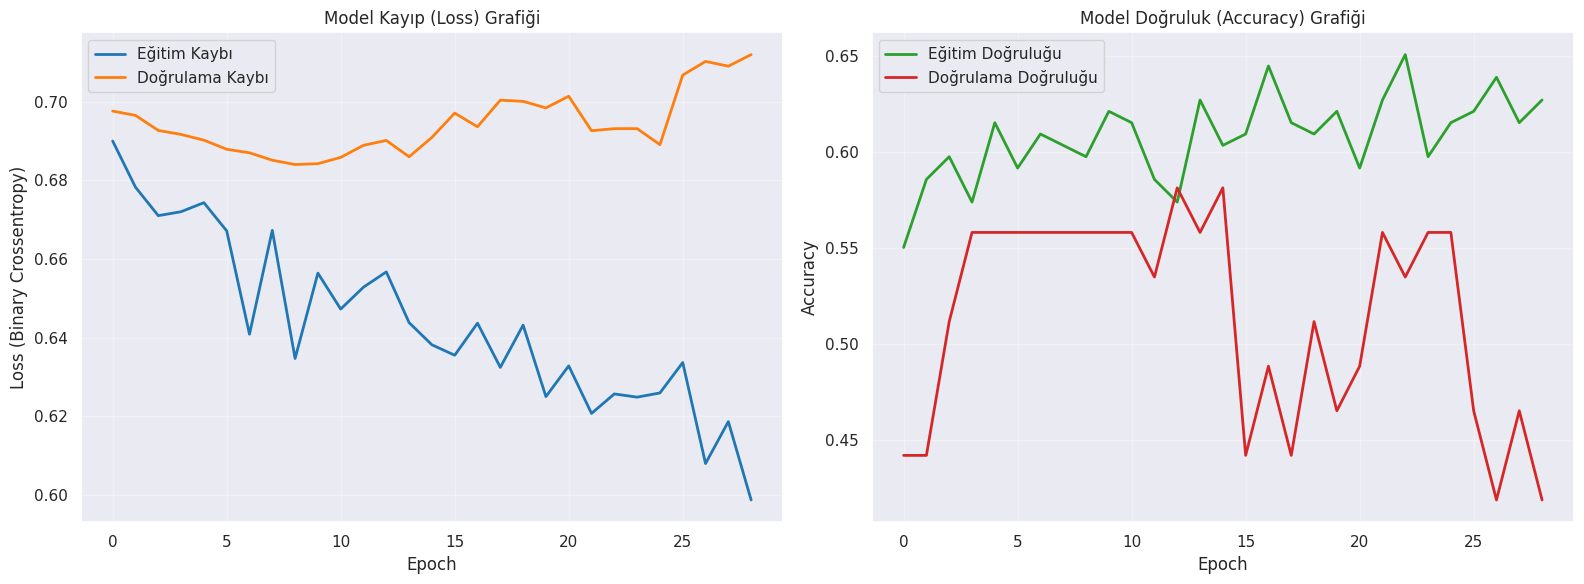

In [ ]:
import matplotlib.pyplot as plt

# Grafiklerin boyutunu ayarlayalım
plt.figure(figsize=(16, 6))

# 1. Grafik: Kayıp (Loss)
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Eğitim Kaybı', color='#1f77b4', linewidth=2)
plt.plot(history.history['val_loss'], label='Doğrulama Kaybı', color='#ff7f0e', linewidth=2)
plt.title('Model Kayıp (Loss) Grafiği')
plt.xlabel('Epoch')
plt.ylabel('Loss (Binary Crossentropy)')
plt.legend()
plt.grid(True, alpha=0.3)

# 2. Grafik: Doğruluk (Accuracy)
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Eğitim Doğruluğu', color='#2ca02c', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Doğrulama Doğruluğu', color='#d62728', linewidth=2)
plt.title('Model Doğruluk (Accuracy) Grafiği')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

y_pred_probs = model.predict(X_test)

y_pred = (y_pred_probs > 0.5).astype(int)

cm = confusion_matrix(y_test, y_pred)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 358ms/step


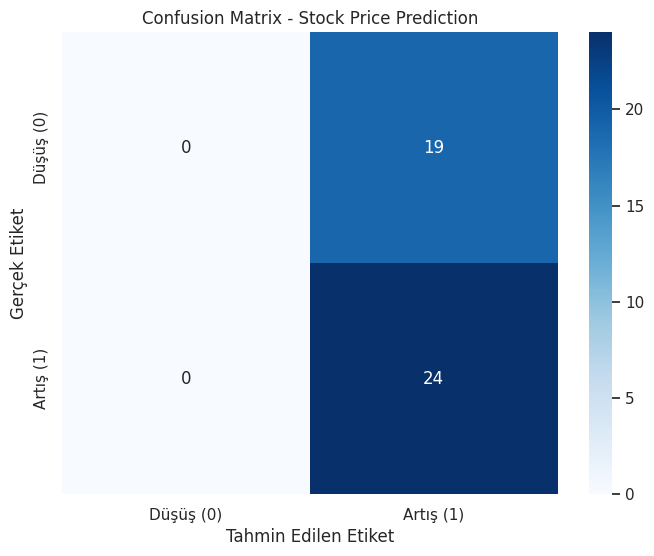

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        19
           1       0.56      1.00      0.72        24

    accuracy                           0.56        43
   macro avg       0.28      0.50      0.36        43
weighted avg       0.31      0.56      0.40        43



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Düşüş (0)', 'Artış (1)'],
            yticklabels=['Düşüş (0)', 'Artış (1)'])
plt.xlabel('Tahmin Edilen Etiket')
plt.ylabel('Gerçek Etiket')
plt.title('Confusion Matrix - Stock Price Prediction')
plt.show()

print(classification_report(y_test, y_pred))

# **Bi-LSTM VERİ SETİNİ 5 YILLIK OLARAK ALDIK VE VERİ SETİ ÜZERİNDE FİYAT DEĞİŞİKLİK YÖNÜ, HIZI OYNAKLIK, BİLGİLERİNİ EKLEDİK GERÇEK SONÇLARI ALDIK. EN İYİ SONUÇ BURASI**

In [ ]:
!pip install pandas_ta

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 5.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 240.3/240.3 kB 17.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.9/3.9 MB 104.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.5/16.5 MB 117.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 144.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.4/42.4 MB 58.5 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
  Attempting uninstall: llvmlite
    Found existing installation: llvmlite 0.43.0
    Uninstalling llvmlite-0.43.0:
      Successfully uninstalled llvmlite-0.43.0
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully unin

In [ ]:

import yfinance as yf
import pandas as pd
import pandas_ta as ta

TICKER = 'GOOG'
START_DATE = '2015-01-01'
END_DATE = '2020-01-01'

data = yf.download(TICKER, start=START_DATE, end=END_DATE)

if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.get_level_values(0)

if data.empty:
    print(f"Veri çekilemedi. Ticker: {TICKER}")
else:
    print(f"'{TICKER}' için {len(data)} satır ham OHLCV verisi çekildi.")
    print("--- Ham Veri (Düzeltilmiş Sütunlar) ---")
    print(data.tail())

    # fiyat değişimlerinin hızı ve büyüklüğü
    data.ta.rsi(length=14, append=True)

    #trendin yönü
    data.ta.macd(fast=12, slow=26, signal=9, append=True)

    # oynaklık
    data.ta.bbands(length=20, std=2, append=True)

    #Volatilite ölçer
    data.ta.atr(length=14, append=True)

    data.dropna(inplace=True)

    print(data.tail())


/tmp/ipython-input-2975335395.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(TICKER, start=START_DATE, end=END_DATE)
[*********************100%***********************]  1 of 1 completed

'GOOG' için 1258 satır ham OHLCV verisi çekildi.
--- Ham Veri (Düzeltilmiş Sütunlar) ---
Price           Close       High        Low       Open    Volume
Date                                                            
2019-12-24  66.677910  67.010415  66.639199  66.923073   6950000
2019-12-26  67.513634  67.559645  66.723070  66.807436  13350000
2019-12-27  67.091301  67.718600  66.963263  67.642170  20768000
2019-12-30  66.309662  67.146389  66.204448  66.997504  21018000
2019-12-31  66.353340  66.401979  65.959542  66.010415  19236000
Price           Close       High        Low       Open    Volume     RSI_14  \
Date                                                                          
2019-12-24  66.677910  67.010415  66.639199  66.923073   6950000  58.411359   
2019-12-26  67.513634  67.559645  66.723070  66.807436  13350000  65.243271   
2019-12-27  67.091301  67.718600  66.963263  67.642170  20768000  59.889103   
2019-12-30  66.309662  67.146389  66.204448  66.997504  21018

In [ ]:
import pandas as pd
import numpy as np

# 1. Günlük Yüzde Değişim (Fiyattan daha stabil bir girdidir)
data['Returns'] = data['Close'].pct_change()

# 2. Hareketli Ortalamalar (5 ve 20 günlük)
data['SMA_5'] = data['Close'].rolling(window=5).mean()
data['SMA_20'] = data['Close'].rolling(window=20).mean()

delta = data['Close'].diff()
gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
rs = gain / loss
data['RSI'] = 100 - (100 / (1 + rs))

data.dropna(inplace=True)

feature_cols = ['Open', 'High', 'Low', 'Close', 'Volume', 'Returns', 'SMA_5', 'SMA_20', 'RSI']
features = data[feature_cols]
target = (data['Close'].shift(-1) > data['Close']).astype(int)[:-1]
features = features[:-1]

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(features)

In [ ]:
def create_sequences(data, target, window_size):
    X = []
    y = []
    for i in range(window_size, len(data)):
        X.append(data[i-window_size:i])
        y.append(target.iloc[i])
    return np.array(X), np.array(y)


WINDOW_SIZE = 20
X, y = create_sequences(scaled_data, target, WINDOW_SIZE)

print(f"X formatı: {X.shape}")
print(f"y formatı: {y.shape}")

X formatı: (1185, 20, 9)
y formatı: (1185,)


In [ ]:
train_size = int(len(X) * 0.8)

X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

print(f"Eğitim seti boyutu: {X_train.shape}")
print(f"Test seti boyutu: {X_test.shape}")

Eğitim seti boyutu: (948, 20, 9)
Test seti boyutu: (237, 20, 9)


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional, BatchNormalization, Input

model = Sequential()

model.add(Input(shape=(X_train.shape[1], X_train.shape[2])))


model.add(Bidirectional(LSTM(units=64, return_sequences=True)))
model.add(BatchNormalization())
model.add(Dropout(0.3))

model.add(Bidirectional(LSTM(units=32, return_sequences=False)))
model.add(Dropout(0.3))

model.add(Dense(units=16, activation='relu'))
model.add(Dense(units=8, activation='relu'))

model.add(Dense(units=1, activation='sigmoid'))

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 20, 128)        │        37,888 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 20, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 20, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 64)             │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 80,801 (315.63 KB)

 Trainable params: 80,545 (314.63 KB)

 Non-trainable params: 256 (1.00 KB)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)

reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=0.001)

history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=16,
    validation_data=(X_test, y_test),
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.5500 - loss: 0.6827 - val_accuracy: 0.4937 - val_loss: 0.6932 - learning_rate: 0.0010
Epoch 2/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.5637 - loss: 0.6897 - val_accuracy: 0.5865 - val_loss: 0.6839 - learning_rate: 0.0010
Epoch 3/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.5408 - loss: 0.6874 - val_accuracy: 0.5485 - val_loss: 0.6811 - learning_rate: 0.0010
Epoch 4/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.5408 - loss: 0.6896 - val_accuracy: 0.5105 - val_loss: 0.6930 - learning_rate: 0.0010
Epoch 5/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.5588 - loss: 0.6823 - val_accuracy: 0.5654 - val_loss: 0.6874 - learning_rate: 0.0010
Epoch 6/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.5575 - loss: 0.6811 - val_accuracy: 0.5316 - val_loss: 0.6877 - learning_rate: 0.0010
Epoch 7/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.5418 - loss: 0.6856 - 

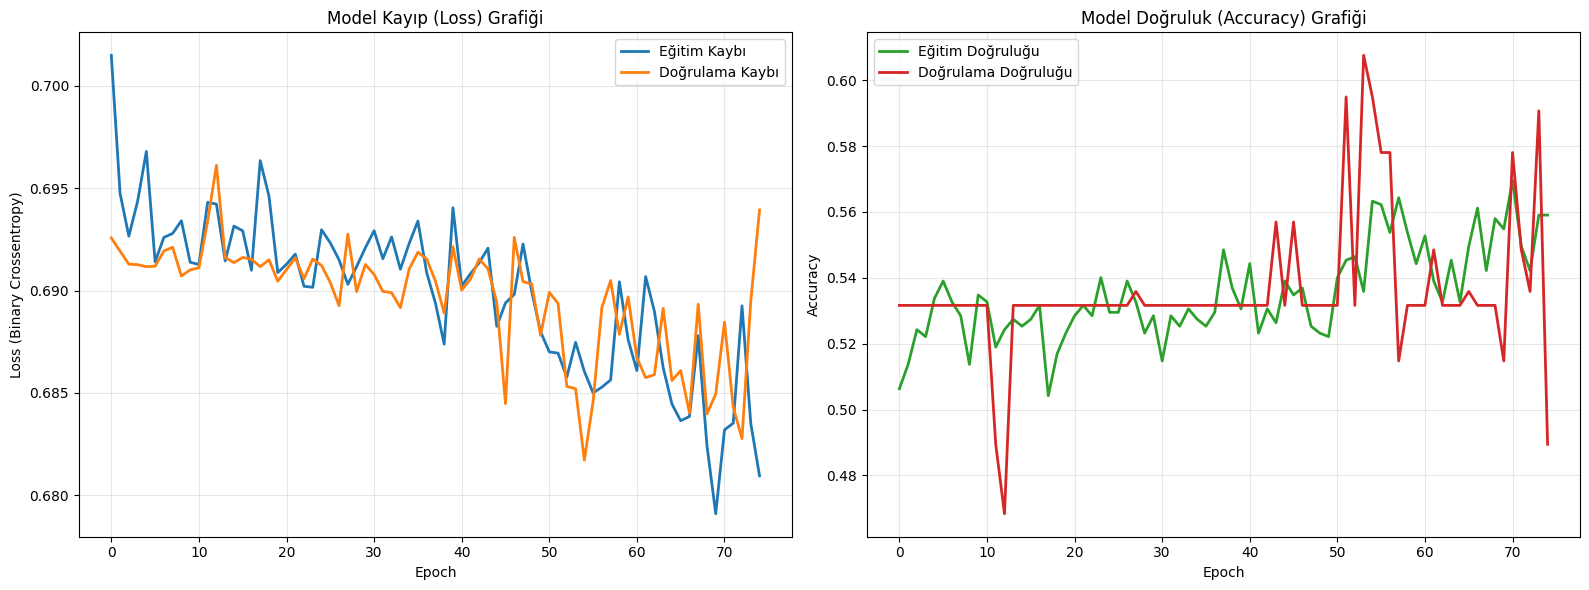

In [ ]:
import matplotlib.pyplot as plt

# Grafiklerin boyutunu ayarlayalım
plt.figure(figsize=(16, 6))

# 1. Grafik: Kayıp (Loss)
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Eğitim Kaybı', color='#1f77b4', linewidth=2)
plt.plot(history.history['val_loss'], label='Doğrulama Kaybı', color='#ff7f0e', linewidth=2)
plt.title('Model Kayıp (Loss) Grafiği')
plt.xlabel('Epoch')
plt.ylabel('Loss (Binary Crossentropy)')
plt.legend()
plt.grid(True, alpha=0.3)

# 2. Grafik: Doğruluk (Accuracy)
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Eğitim Doğruluğu', color='#2ca02c', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Doğrulama Doğruluğu', color='#d62728', linewidth=2)
plt.title('Model Doğruluk (Accuracy) Grafiği')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

y_pred_probs = model.predict(X_test)

y_pred = (y_pred_probs > 0.5).astype(int)

cm = confusion_matrix(y_test, y_pred)

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step


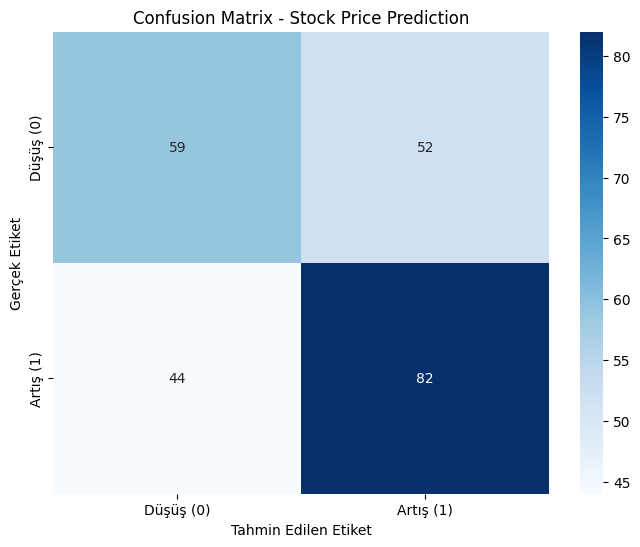

              precision    recall  f1-score   support

           0       0.57      0.53      0.55       111
           1       0.61      0.65      0.63       126

    accuracy                           0.59       237
   macro avg       0.59      0.59      0.59       237
weighted avg       0.59      0.59      0.59       237



In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Düşüş (0)', 'Artış (1)'],
            yticklabels=['Düşüş (0)', 'Artış (1)'])
plt.xlabel('Tahmin Edilen Etiket')
plt.ylabel('Gerçek Etiket')
plt.title('Confusion Matrix - Stock Price Prediction')
plt.show()

print(classification_report(y_test, y_pred))

# **LSTM + FinBERT**

In [ ]:
import tensorflow as tf
from transformers import TFBertModel
from tensorflow.keras.layers import Input, LSTM, Dense, Concatenate, Dropout, Lambda

finbert_model = TFBertModel.from_pretrained("ProsusAI/finbert", from_pt=True)
finbert_model.trainable = True

for layer in finbert_model.bert.encoder.layer[:-2]:
    layer.trainable = False
    # --- NLP KOLU: FinBERT ---
    def get_bert_embeddings(inputs):
        input_ids, attention_mask = inputs
        output = finbert_model(input_ids=input_ids, attention_mask=attention_mask)
        return output[1]


def build_hybrid_model(window_size, num_feature_count, max_seq_len=128):
    # --- GİRİŞLER ---
    ids_in = Input(shape=(max_seq_len,), dtype=tf.int32, name="input_ids")
    mask_in = Input(shape=(max_seq_len,), dtype=tf.int32, name="attention_mask")
    num_in = Input(shape=(window_size, num_feature_count), name="numeric_input")

    # --- NLP KOLU: FinBERT ---
    def get_bert_embeddings(inputs):
        input_ids, attention_mask = inputs
        output = finbert_model(input_ids=input_ids, attention_mask=attention_mask)
        return output[1]

    nlp_out = Lambda(
        get_bert_embeddings,
        output_shape=(768,),
        name="finbert_feature_extractor"
    )([ids_in, mask_in])

    nlp_path = Dense(128, activation='relu')(nlp_out)
    nlp_path = Dropout(0.3)(nlp_path)

    # --- ZAMAN SERİSİ KOLU: LSTM ---
    lstm_path = LSTM(64, return_sequences=True)(num_in)
    lstm_path = LSTM(32, return_sequences=False)(lstm_path)
    lstm_path = Dropout(0.3)(lstm_path)

    # --- BİRLEŞTİRME VE FINAL ---
    combined = Concatenate()([nlp_path, lstm_path])

    dense = Dense(64, activation='relu')(combined)
    dense = Dense(32, activation='relu')(dense)
    output = Dense(1, activation='sigmoid')(dense)

    model = tf.keras.Model(inputs=[ids_in, mask_in, num_in], outputs=output)
    optimizer = tf.keras.optimizers.AdamW(
    learning_rate=1e-5,
    weight_decay=0.01,
    beta_1=0.9,
    beta_2=0.999,
    epsilon=1e-07
    )

    model.compile(
        optimizer=optimizer,
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

model = build_hybrid_model(window_size=5, num_feature_count=15)


model.summary()

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau


checkpoint_path = "/content/drive/MyDrive/Stock Price Direction Prediction/FİNBERT+LSTM/best_model.keras"

callbacks = [

    ModelCheckpoint(checkpoint_path, monitor='val_loss', save_best_only=True, verbose=1),

    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-7, verbose=1)
]


history = model.fit(
    x=train_inputs,
    y=train_y,
    validation_data=(val_inputs, val_y),
    epochs=50,
    batch_size=8,
    callbacks=callbacks,
    shuffle=False
)

Epoch 1/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.4747 - loss: 0.7819
Epoch 1: val_loss improved from inf to 0.77013, saving model to /content/drive/MyDrive/Stock Price Direction Prediction/FİNBERT+LSTM/best_model.keras
31/31 ━━━━━━━━━━━━━━━━━━━━ 15s 160ms/step - accuracy: 0.4748 - loss: 0.7818 - val_accuracy: 0.4615 - val_loss: 0.7701 - learning_rate: 1.0000e-05
Epoch 2/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.4747 - loss: 0.7804
Epoch 2: val_loss improved from 0.77013 to 0.75743, saving model to /content/drive/MyDrive/Stock Price Direction Prediction/FİNBERT+LSTM/best_model.keras
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - accuracy: 0.4748 - loss: 0.7804 - val_accuracy: 0.4615 - val_loss: 0.7574 - learning_rate: 1.0000e-05
Epoch 3/50
30/31 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.4796 - loss: 0.7529
Epoch 3: val_loss improved from 0.75743 to 0.74649, saving model to /content/drive/MyDrive/Stock Price Direction Prediction/FİNBERT+LSTM/best_model.ker

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

y_pred_probs = model.predict(test_inputs)

y_pred = (y_pred_probs > 0.5).astype(int)

cm = confusion_matrix(test_y, y_pred)

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 75ms/step


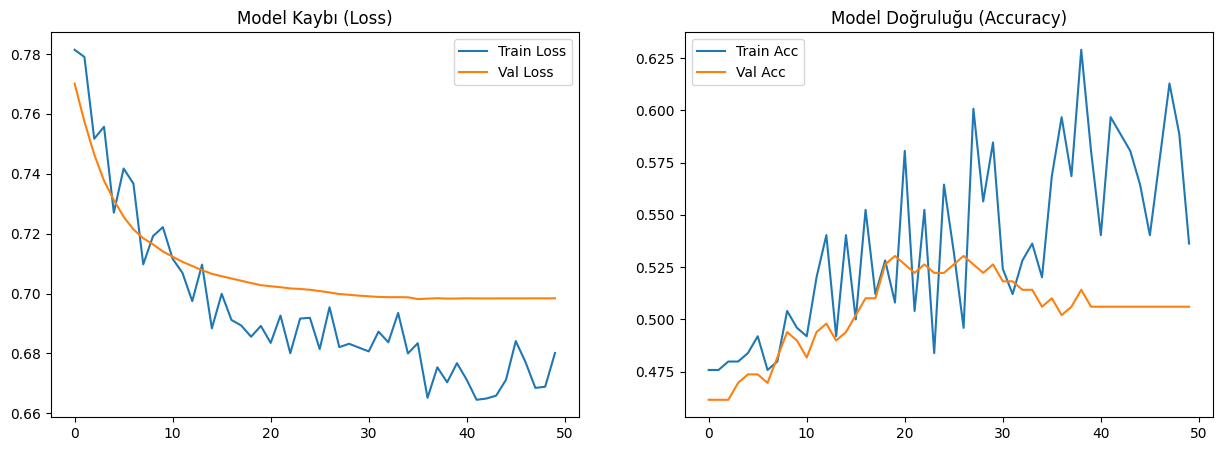

In [ ]:
import matplotlib.pyplot as plt

def plot_history(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    ax1.plot(history.history['loss'], label='Train Loss')
    ax1.plot(history.history['val_loss'], label='Val Loss')
    ax1.set_title('Model Kaybı (Loss)')
    ax1.legend()

    ax2.plot(history.history['accuracy'], label='Train Acc')
    ax2.plot(history.history['val_accuracy'], label='Val Acc')
    ax2.set_title('Model Doğruluğu (Accuracy)')
    ax2.legend()

    plt.show()

plot_history(history)

# **Bi-LSTM + FinBert**

In [ ]:
import pandas as pd
import numpy as np

train_df = pd.read_pickle("/content/drive/MyDrive/Stock Price Direction Prediction/Dataset/train_data.pkl")
val_df   = pd.read_pickle("/content/drive/MyDrive/Stock Price Direction Prediction/Dataset/val_data.pkl")
test_df  = pd.read_pickle("/content/drive/MyDrive/Stock Price Direction Prediction/Dataset/test_data.pkl")
train_df.head()


,Close,High,Low,Open,Volume,RSI_14,MACD_12_26_9,MACDh_12_26_9,MACDs_12_26_9,BBL_20_2.0_2.0,BBM_20_2.0_2.0,BBU_20_2.0_2.0,BBB_20_2.0_2.0,BBP_20_2.0_2.0,ATRr_14,daily_news,Target,input_ids,attention_mask
Date,,,,,,,,,,,,,,,,,,,
2010-02-22,20.673571,21.085706,20.383963,21.085706,18421115,46.955048,-0.262415,0.076121,-0.338536,19.931729,20.954269,21.976810,9.759735,0.362744,0.552958,,0,"[101, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","[1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
2010-02-23,20.333839,20.684710,20.272574,20.551044,16699670,42.187404,-0.279555,0.047184,-0.326740,19.878783,20.891613,21.904444,9.696050,0.224646,0.542899,,1,"[101, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","[1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
2010-02-24,20.567751,20.629014,20.200173,20.439656,17913988,46.235215,-0.271139,0.044481,-0.315619,19.863595,20.845666,21.827737,9.422303,0.358506,0.534752,,0,"[101, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","[1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
2010-02-25,20.367254,20.417378,20.077645,20.294852,17854252,43.428412,-0.277449,0.030537,-0.307985,19.837816,20.788023,21.738230,9.141872,0.278591,0.531563,Eli Lilly Banks On Its Restructured Developmen...,1,"[101, 12005, 14765, 5085, 2006, 2049, 2717, 26...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
2010-02-26,20.539911,20.640159,20.294857,20.439662,13800483,46.443586,-0.265457,0.034022,-0.299480,19.817006,20.757670,21.698334,9.063291,0.384253,0.518259,,1,"[101, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","[1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."


In [ ]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.preprocessing.sequence import pad_sequences

WINDOW_SIZE = 5
MAX_LEN = 128
NUM_FEATURES = ['Close', 'High', 'Low', 'Open', 'Volume', 'RSI_14',
                'MACD_12_26_9', 'MACDh_12_26_9', 'MACDs_12_26_9',
                'BBL_20_2.0_2.0', 'BBM_20_2.0_2.0', 'BBU_20_2.0_2.0',
                'BBB_20_2.0_2.0', 'BBP_20_2.0_2.0', 'ATRr_14']

def prepare_inputs(df, scaler=None, fit_scaler=False):
    if fit_scaler:
        scaler = StandardScaler()
        scaled_nums = scaler.fit_transform(df[NUM_FEATURES])
    else:
        scaled_nums = scaler.transform(df[NUM_FEATURES])

    X_num, X_ids, X_mask, y = [], [], [], []

    for i in range(WINDOW_SIZE, len(df)):
        X_num.append(scaled_nums[i-WINDOW_SIZE:i])
        X_ids.append(df.iloc[i]['input_ids'])
        X_mask.append(df.iloc[i]['attention_mask'])
        y.append(df.iloc[i]['Target'])

    X_ids = pad_sequences(X_ids, maxlen=MAX_LEN, padding='post', truncating='post')
    X_mask = pad_sequences(X_mask, maxlen=MAX_LEN, padding='post', truncating='post')
    X_num = np.array(X_num, dtype='float32')
    y = np.array(y, dtype='float32')

    return [X_ids, X_mask, X_num], y, scaler

train_inputs, train_y, scaler = prepare_inputs(train_df_1y, fit_scaler=True)
val_inputs, val_y, _ = prepare_inputs(val_df_1y, scaler=scaler)
test_inputs, test_y, _ = prepare_inputs(test_df_1y, scaler=scaler)

In [ ]:
import tensorflow as tf
from transformers import TFBertModel
from tensorflow.keras.layers import Input, LSTM, Dense, Concatenate, Dropout, Lambda

finbert_model = TFBertModel.from_pretrained("ProsusAI/finbert", from_pt=True)
finbert_model.trainable = True

# Ama sadece son 2 encoder katmanını eğitime aç, gerisini dondur
for layer in finbert_model.bert.encoder.layer[:-2]:
    layer.trainable = False
    # --- NLP KOLU: FinBERT ---
    def get_bert_embeddings(inputs):
        input_ids, attention_mask = inputs
        output = finbert_model(input_ids=input_ids, attention_mask=attention_mask)
        return output[1]


def build_hybrid_model(window_size, num_feature_count, max_seq_len=128):
    # --- GİRİŞLER ---
    ids_in = Input(shape=(max_seq_len,), dtype=tf.int32, name="input_ids")
    mask_in = Input(shape=(max_seq_len,), dtype=tf.int32, name="attention_mask")
    num_in = Input(shape=(window_size, num_feature_count), name="numeric_input")

    # --- NLP KOLU: FinBERT ---
    def get_bert_embeddings(inputs):
        input_ids, attention_mask = inputs
        output = finbert_model(input_ids=input_ids, attention_mask=attention_mask)
        return output[1]

    nlp_out = Lambda(
        get_bert_embeddings,
        output_shape=(768,),
        name="finbert_feature_extractor"
    )([ids_in, mask_in])

    nlp_path = Dense(128, activation='relu')(nlp_out)
    nlp_path = Dropout(0.3)(nlp_path)

    # --- ZAMAN SERİSİ KOLU: LSTM ---

    lstm_path = LSTM(64, return_sequences=True)(num_in)
    lstm_path = LSTM(32, return_sequences=False)(lstm_path)
    lstm_path = Dropout(0.3)(lstm_path)

    # --- BİRLEŞTİRME VE FINAL ---
    combined = Concatenate()([nlp_path, lstm_path])

    dense = Dense(64, activation='relu')(combined)
    dense = Dense(32, activation='relu')(dense)
    output = Dense(1, activation='sigmoid')(dense)

    model = tf.keras.Model(inputs=[ids_in, mask_in, num_in], outputs=output)
    optimizer = tf.keras.optimizers.AdamW(
    learning_rate=1e-5,
    weight_decay=0.01,
    beta_1=0.9,
    beta_2=0.999,
    epsilon=1e-07
    )

    model.compile(
        optimizer=optimizer,
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

model = build_hybrid_model(window_size=5, num_feature_count=15)


model.summary()

Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFBertModel: ['classifier.weight', 'classifier.bias', 'bert.embeddings.position_ids']
- This IS expected if you are initializing TFBertModel from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFBertModel from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
All the weights of TFBertModel were initialized from the PyTorch model.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFBertModel for predictions without further training.


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_ids           │ (None, 128)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_mask      │ (None, 128)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ numeric_input       │ (None, 5, 15)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ finbert_feature_ex… │ (None, 768)       │          0 │ input_ids[0][0],  │
│ (Lambda)            │                   │            │ attention_mask[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_2 (LSTM)       │ (None, 5, 64)     │     20,480 │ numeric_input[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 128)       │     98,432 │ finbert_feature_… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_3 (LSTM)       │ (None, 32)        │     12,416 │ lstm_2[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 128)       │          0 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 32)        │          0 │ lstm_3[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 160)       │          0 │ dropout_2[0][0],  │
│ (Concatenate)       │                   │            │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 64)        │     10,304 │ concatenate_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 32)        │      2,080 │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 1)         │         33 │ dense_6[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 143,745 (561.50 KB)

 Trainable params: 143,745 (561.50 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau


checkpoint_path = "/content/drive/MyDrive/Stock Price Direction Prediction/FİNBERT+LSTM/best_model.keras"

callbacks = [

    ModelCheckpoint(checkpoint_path, monitor='val_loss', save_best_only=True, verbose=1),

    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-7, verbose=1)
]


history = model.fit(
    x=train_inputs,
    y=train_y,
    validation_data=(val_inputs, val_y),
    epochs=50,
    batch_size=8,
    callbacks=callbacks,
    shuffle=False
)

Epoch 1/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.4747 - loss: 0.7819
Epoch 1: val_loss improved from inf to 0.77013, saving model to /content/drive/MyDrive/Stock Price Direction Prediction/FİNBERT+LSTM/best_model.keras
31/31 ━━━━━━━━━━━━━━━━━━━━ 15s 160ms/step - accuracy: 0.4748 - loss: 0.7818 - val_accuracy: 0.4615 - val_loss: 0.7701 - learning_rate: 1.0000e-05
Epoch 2/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.4747 - loss: 0.7804
Epoch 2: val_loss improved from 0.77013 to 0.75743, saving model to /content/drive/MyDrive/Stock Price Direction Prediction/FİNBERT+LSTM/best_model.keras
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - accuracy: 0.4748 - loss: 0.7804 - val_accuracy: 0.4615 - val_loss: 0.7574 - learning_rate: 1.0000e-05
Epoch 3/50
30/31 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.4796 - loss: 0.7529
Epoch 3: val_loss improved from 0.75743 to 0.74649, saving model to /content/drive/MyDrive/Stock Price Direction Prediction/FİNBERT+LSTM/best_model.ker

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

y_pred_probs = model.predict(test_inputs)

y_pred = (y_pred_probs > 0.5).astype(int)

cm = confusion_matrix(test_y, y_pred)

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 75ms/step


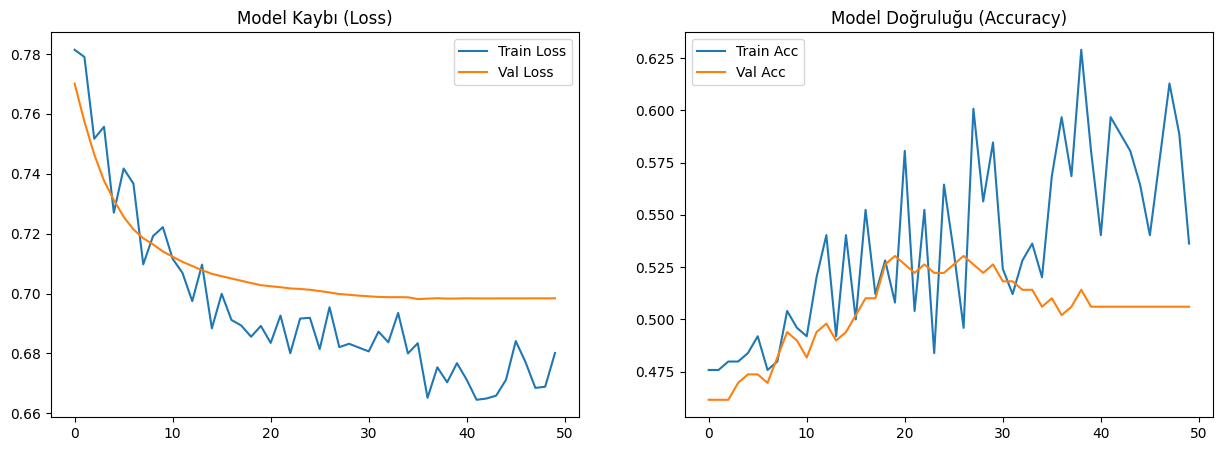

In [ ]:
import matplotlib.pyplot as plt

def plot_history(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    ax1.plot(history.history['loss'], label='Train Loss')
    ax1.plot(history.history['val_loss'], label='Val Loss')
    ax1.set_title('Model Kaybı (Loss)')
    ax1.legend()

    ax2.plot(history.history['accuracy'], label='Train Acc')
    ax2.plot(history.history['val_accuracy'], label='Val Acc')
    ax2.set_title('Model Doğruluğu (Accuracy)')
    ax2.legend()

    plt.show()

plot_history(history)

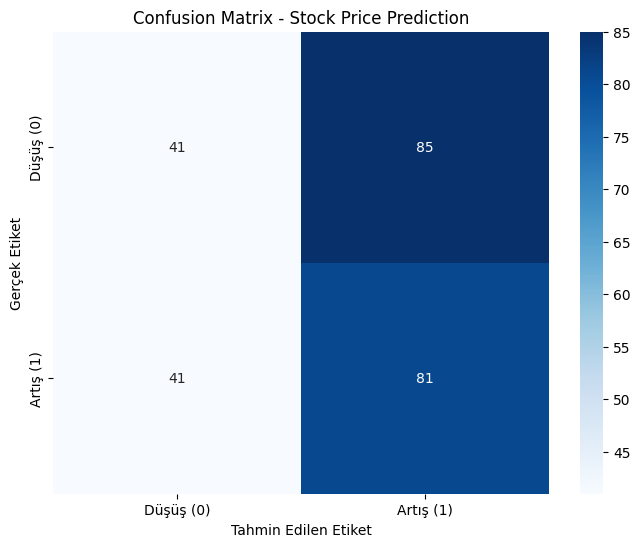

              precision    recall  f1-score   support

         0.0       0.50      0.33      0.39       126
         1.0       0.49      0.66      0.56       122

    accuracy                           0.49       248
   macro avg       0.49      0.49      0.48       248
weighted avg       0.49      0.49      0.48       248



In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Düşüş (0)', 'Artış (1)'],
            yticklabels=['Düşüş (0)', 'Artış (1)'])
plt.xlabel('Tahmin Edilen Etiket')
plt.ylabel('Gerçek Etiket')
plt.title('Confusion Matrix - Stock Price Prediction')
plt.show()

print(classification_report(test_y, y_pred))

# Stock Price Direction Prediction

This project aims to predict the daily price movement direction (up or down) of stocks (e.g., GOOG, MRK) using historical stock data and financial news headlines, utilizing deep learning-based approaches.

In this project, not only price and volume information but also technical indicators and Natural Language Processing (NLP)-based sentiment analysis are combined to develop **Multimodal** models.

## 🚀 Features

- **Time Series Analysis:** Fetching historical stock data (OHLCV) using the YFinance library.
- **Technical Indicators (pandas_ta):** Adding features like RSI, MACD, Bollinger Bands (BBANDS), ATR, and Simple Moving Averages (SMA) to the dataset, and making the data stationary (Log-returns).
- **Natural Language Processing (FinBERT):** Integrating daily financial news headlines by embedding them using the HuggingFace `ProsusAI/finbert` model.
- **Advanced Models:**
  - **LSTM** and **Bi-LSTM** models using only numerical (technical) data.
  - Hybrid **FinBERT + CNN + LSTM** architecture combining numerical and text data.
  - Hybrid **FinBERT + Bi-LSTM** architecture, which yielded the best results.
- **Walk-Forward Validation:** Testing model robustness using the Time Series Split cross-validation method suitable for time series.

## 🛠️ Installation and Requirements

To run the project in your local environment or on Google Colab, the following libraries must be installed:

```bash
pip install tensorflow transformers yfinance pandas numpy pandas_ta scikit-learn matplotlib seaborn
```

*Note: PyTorch and Transformers libraries are downloaded in the background to use the FinBERT model.*

## 📊 Dataset Preparation

1. **Price Data:** Stock data for specific date ranges are downloaded via `yfinance`.
2. **Technical Indicators:** RSI, MACD, etc., are calculated using the `pandas_ta` library.
3. **Labeling (Target):** If the next day's closing price is higher than today's closing price, it is labeled as `1` (Up); if lower, `0` (Down).
4. **News Data:** The analyst/news dataset in CSV format is filtered by stock and merged on a daily basis.

## 🧠 Models and Performance Evaluation

Model performances were evaluated using Accuracy, Precision, Recall, F1-Score, and Matthews Correlation Coefficient (MCC) metrics. Visualizations are provided via the Confusion Matrix.

- **Bi-LSTM Model:** Yielded one of the most consistent and best results on the 5-year extended dataset with technical indicators.
- **FinBERT + LSTM/Bi-LSTM (Hybrid):** An advanced structure combining the NLP (text) and technical (numerical) branches was used to model the relationship between market sentiment and trends.

## 📌 Usage

To run the project:
1. Open the Notebook file (`.ipynb`) using Jupyter Notebook or Google Colab.
2. If you are using data from Google Drive, mount your Drive in the relevant cell (`drive.mount`).
3. Update the file paths of the datasets according to your own directory structure.
4. Run the cells sequentially to fetch the data, complete preprocessing, and train the models.

## 🤝 Contributing

This project is open to contributions. If you find any bugs or have suggestions for improvement, please open an **Issue** or submit a **Pull Request**.

## 📄 License

This project is licensed under the MIT License.


In [4]:
import json

# Notebook dosyanızın Drive'daki tam yolu
notebook_path = '/content/drive/MyDrive/Stock Price Direction Prediction/Scripts/Stock_Price_Direction_Prediction.ipynb'

try:
    with open(notebook_path, 'r', encoding='utf-8') as f:
        nb = json.load(f)

    # Sorunlu widget meta verilerini temizle
    if 'widgets' in nb.get('metadata', {}):
        del nb['metadata']['widgets']
        print("Widget meta verisi başarıyla silindi.")
    else:
        print("Bu dosyada widget meta verisi bulunamadı. Lütfen GitHub'a yüklemeyi tekrar deneyin.")

    # Temizlenmiş dosyayı üzerine yaz (çıktılarınız silinmez)
    with open(notebook_path, 'w', encoding='utf-8') as f:
        json.dump(nb, f, indent=1)

    print(f"\nİşlem Tamam!\n{notebook_path} temizlendi.\nArtık bu dosyayı Drive'dan bilgisayarınıza indirip GitHub'a sorunsuzca yükleyebilirsiniz.")
except FileNotFoundError:
    print(f"Hata: '{notebook_path}' dosyası bulunamadı. Lütfen dosya yolunu kontrol edin.")
except Exception as e:
    print(f"Bir hata oluştu: {e}")

Bu dosyada widget meta verisi bulunamadı. Lütfen GitHub'a yüklemeyi tekrar deneyin.

İşlem Tamam!
/content/drive/MyDrive/Stock Price Direction Prediction/Scripts/Stock_Price_Direction_Prediction.ipynb temizlendi.
Artık bu dosyayı Drive'dan bilgisayarınıza indirip GitHub'a sorunsuzca yükleyebilirsiniz.
